# PROVA-AD

### A Provenance-Gated Dual-Stream Network with a Differentiable Cost-Calibrated Decision Head for Leakage-Audited Alzheimer's Disease Classification

**MD. Bakibillah Rahat · Naima Najam Nejum**
Department of Computer Science, American International University-Bangladesh

---

This notebook is the complete, self-contained implementation and experimental
record for the accompanying manuscript. It defines the architecture from
scratch, runs every experiment, and produces every table and figure in the
paper. There are no external project imports — only NumPy, pandas,
scikit-learn, SciPy and Matplotlib. No GPU and no deep-learning framework are
required; the proposed decision head is written directly in NumPy with
hand-derived gradients.

**Run the cells top to bottom.** Total runtime is roughly 40 minutes on a
CPU-only machine.

---

## What the model is, in one paragraph

Tabular Alzheimer's benchmarks report 95 %+ accuracy that comes almost entirely
from ten clinician-administered assessment items — instruments produced *by* the
diagnostic work-up the model is supposed to predict. No conventional
architecture can report how much of a given prediction rested on those items,
because a flat feature vector carries no record of where each feature came
from. PROVA-AD makes provenance a first-class architectural object:

| Stage | Component | What it contributes |
|---|---|---|
| **1** | Provenance-Partitioned Stream Encoder | three parallel banks of *K*=4 heterogeneous learners on the screening stream, the clinical stream and their union, giving provenance-**indexed** meta-features |
| **2** | Provenance Gate and Cross-Stream Fusion | a gate that sees screening features only, emitting a per-patient reliance coefficient α(*x*) ∈ (0,1) and fusing ℓ = α·e_c + (1−α)·e_s + vᵀz̃ + b₀ |
| **3** | Differentiable Cost-Calibrated Decision Head | a monotone spline Γ_θ trained *jointly* with a proper scoring rule, a soft-binned calibration penalty and a smoothed clinical decision cost |

Because Stage 3 produces calibrated probabilities, the cost-optimal operating
point follows in **closed form**, τ\* = c_FP/(c_FP + c_FN) = 1/6 for the 5:1
clinical cost used here — so no labelled threshold-tuning set is needed.

---

## Notebook map

| § | Cells | Paper section | Produces |
|---|---|---|---|
| 0 | environment | — | seed, versions, global configuration |
| 1 | data | V | cohort, provenance partition, correlations (Table II) |
| 2 | Stage 1 | VI-C | encoder banks |
| 3 | Stages 2–3 | VI-D, VI-E, VI-F | the novel head + analytic-gradient verification |
| 4 | estimator | VI-H | `ProvaAD` and the nested 5×5-fold protocol |
| 5 | metrics | VII-C, VII-D | metrics, ECE, bootstrap, McNemar, cost curve |
| 6 | baselines | VIII-A | eleven reference classifiers |
| 7–8 | tracks | VIII-A, VIII-B | Tables V and VI, leakage audit |
| 9–10 | PROVA-AD | VIII-A, VIII-B | main result + screening collapse |
| 11–12 | statistics | VIII-A, VIII-D | CIs, McNemar, closed-form threshold check |
| 13 | gate | VIII-E | provenance-reliance analysis |
| 14–15 | ablation | VIII-G | Tables VII and VIII |
| 16–18 | robustness | VIII-H, VIII-I, VIII-F | learning curve, domain shift, attribution |
| 19–20 | cost, external | VIII-K, IX | complexity, external-cohort hook |
| 21 | figures | all | every figure in the paper |

---
## 0. Environment and global configuration

Every experiment is driven by the constants in this cell, so a single edit here
changes the whole study consistently. `SEED` controls every split, every
learner and every parameter initialisation.

In [2]:
import json, os, re, sys, time, warnings
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

import sklearn
from sklearn.calibration import calibration_curve
from sklearn.ensemble import (AdaBoostClassifier, ExtraTreesClassifier,
                              GradientBoostingClassifier,
                              HistGradientBoostingClassifier,
                              RandomForestClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             average_precision_score, brier_score_loss,
                             cohen_kappa_score, confusion_matrix, f1_score,
                             matthews_corrcoef, precision_recall_curve,
                             precision_score, recall_score, roc_auc_score,
                             roc_curve)
from sklearn.model_selection import (StratifiedKFold, cross_val_predict,
                                     train_test_split)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

# ---------------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------------
SEED         = 42
N_OUTER_FOLDS = 5     # outer evaluation loop
N_INNER_FOLDS = 5     # inner loop producing the head's out-of-fold meta-features
N_BOOTSTRAP   = 2000

# ---------------------------------------------------------------------
# Clinical cost model.  A missed AD case is penalised FN_COST times more
# heavily than an unnecessary follow-up.
# ---------------------------------------------------------------------
FN_COST = 5.0
FP_COST = 1.0

#: Bayes-optimal decision threshold under calibrated probabilities (Prop. 1)
TAU_STAR = FP_COST / (FP_COST + FN_COST)

# ---------------------------------------------------------------------
# Provenance partition.  These ten attributes are produced *by* the clinical
# work-up that yields the diagnosis; everything else is available before any
# cognitive assessment has been administered.
# ---------------------------------------------------------------------
CLINICAL_FEATURES = (
    "MMSE", "FunctionalAssessment", "ADL", "MemoryComplaints",
    "BehavioralProblems", "Confusion", "Disorientation", "PersonalityChanges",
    "DifficultyCompletingTasks", "Forgetfulness",
)
DROP_COLUMNS = ("PatientID", "DoctorInCharge")
TARGET = "Diagnosis"

# ---------------------------------------------------------------------
# PROVA-AD hyperparameters (Table IV of the paper)
# ---------------------------------------------------------------------
GATE_HIDDEN   = 16      # H,   width of the provenance-gate hidden layer
SPLINE_KNOTS  = 16      # M,   monotone calibration spline resolution
CAL_BINS      = 15      # M_b, soft bins for the differentiable ECE term
LAMBDA_CAL    = 1.0     # lambda_cal   (soft-ECE reliability penalty)
LAMBDA_COST   = 0.5     # lambda_cost  (smoothed decision-cost term)
COST_TEMP     = 0.10    # T,   temperature of the soft decision indicator
LAMBDA_ENT    = 0.05    # lambda_ent   (gate-entropy / routing crispness)
LAMBDA_L2     = 1e-4    # weight decay
LEARNING_RATE = 0.02
EPOCHS        = 400

FIGURES_DIR = "figures"
RESULTS_DIR = "results"
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

RESULTS = {}          # every exported table/scalar lands here

def export(name, obj):
    """Persist a result and keep it in the in-memory registry."""
    RESULTS[name] = obj
    path = os.path.join(RESULTS_DIR, name)
    if isinstance(obj, pd.DataFrame):
        obj.to_csv(path + ".csv", index=False)
    else:
        with open(path + ".json", "w") as fh:
            json.dump(obj, fh, indent=2, default=float)
    return obj

print("python       ", sys.version.split()[0])
print("numpy        ", np.__version__)
print("pandas       ", pd.__version__)
print("scikit-learn ", sklearn.__version__)
print("matplotlib   ", matplotlib.__version__)
print()
print("seed", SEED, "| outer folds", N_OUTER_FOLDS, "| inner folds", N_INNER_FOLDS,
      "| bootstrap", N_BOOTSTRAP)
print(f"cost ratio c_FN:c_FP = {FN_COST:.0f}:{FP_COST:.0f}"
      f"  ->  closed-form tau* = {TAU_STAR:.4f}")

python        3.12.13
numpy         2.0.2
pandas        2.3.3
scikit-learn  1.6.1
matplotlib    3.10.0

seed 42 | outer folds 5 | inner folds 5 | bootstrap 2000
cost ratio c_FN:c_FP = 5:1  ->  closed-form tau* = 0.1667


In [3]:
from pathlib import Path

# Keep exported artifacts beside the notebook, regardless of the kernel cwd.
PROJECT_ROOT = Path.cwd()
for candidate in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (candidate / "data" / "data_alzheimers.csv").exists():
        PROJECT_ROOT = candidate
        break

FIGURES_DIR = PROJECT_ROOT / "figures"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"project root  {PROJECT_ROOT}")
print(f"figures      {FIGURES_DIR}")
print(f"results      {RESULTS_DIR}")

project root  /kaggle/working
figures      /kaggle/working/figures
results      /kaggle/working/results


---
## 1. Cohort and the provenance partition  *(paper Section V, Table II)*

The whole study rests on one modelling decision: predictors are partitioned by
**where they came from**, not by what they measure. Ten attributes are produced
by the clinical work-up that yields the diagnosis; the remaining 22 are
available before any cognitive assessment has been administered.

$$\{1,\dots,32\} \;=\; \mathcal{S}\,\dot\cup\,\mathcal{C},
\qquad |\mathcal{S}| = 22,\; |\mathcal{C}| = 10$$

In [4]:
from dataclasses import dataclass

import numpy as np
import pandas as pd



@dataclass
class Cohort:
    """A provenance-partitioned patient cohort."""

    frame: pd.DataFrame
    X: pd.DataFrame          # all predictors (d = d_s + d_c)
    y: np.ndarray            # binary diagnosis
    screening: list[str]     # names of pre-assessment features
    clinical: list[str]      # names of clinician-administered features
    name: str = "primary"

    @property
    def Xs(self) -> pd.DataFrame:
        return self.X[self.screening]

    @property
    def Xc(self) -> pd.DataFrame:
        return self.X[self.clinical]

    def summary(self) -> dict:
        pos = int(self.y.sum())
        return {
            "cohort": self.name,
            "n_records": int(len(self.y)),
            "n_features": int(self.X.shape[1]),
            "n_screening": len(self.screening),
            "n_clinical": len(self.clinical),
            "n_positive": pos,
            "n_negative": int(len(self.y) - pos),
            "positive_rate": round(float(self.y.mean()), 4),
        }


def load_cohort(path: str = "data_alzheimers.csv", name: str = "primary",
                target: str = TARGET,
                clinical: tuple[str, ...] = CLINICAL_FEATURES,
                drop: tuple[str, ...] = DROP_COLUMNS) -> Cohort:
    """Load a tabular AD cohort and split its features by provenance.

    Any column listed in ``clinical`` that is present in the file is routed to
    the clinical stream; every other predictor is treated as screening-stage
    information.  This makes the loader reusable for an external cohort whose
    assessment battery is only partly overlapping.
    """
    df = pd.read_csv(path)
    df = df.drop(columns=[c for c in drop if c in df.columns])
    y = df[target].astype(int).to_numpy()
    X = df.drop(columns=[target])

    # keep only numeric predictors; encode any object columns ordinally
    for col in X.columns:
        if not np.issubdtype(X[col].dtype, np.number):
            X[col] = pd.Categorical(X[col]).codes
    X = X.astype(float)

    clin = [c for c in clinical if c in X.columns]
    scre = [c for c in X.columns if c not in clin]
    return Cohort(frame=df, X=X, y=y, screening=scre, clinical=clin, name=name)


def correlation_report(cohort: Cohort) -> pd.DataFrame:
    """|Pearson r| between every predictor and the diagnosis, tagged by stream."""
    r = cohort.X.apply(lambda c: np.corrcoef(c, cohort.y)[0, 1])
    out = pd.DataFrame({
        "feature": r.index,
        "r": r.values,
        "abs_r": np.abs(r.values),
        "stream": ["clinical" if f in cohort.clinical else "screening" for f in r.index],
    })
    return out.sort_values("abs_r", ascending=False).reset_index(drop=True)


def shifted_cohorts(cohort: Cohort, column: str, threshold: float):
    """Split a cohort into a source and a target sub-cohort on ``column``.

    Used for the internal domain-shift protocol (Section VII-D): the model is
    fitted on the source stratum only and evaluated on the disjoint target
    stratum, so the evaluation cohort differs from the training cohort in a
    controlled, clinically meaningful way.
    """
    v = cohort.X[column].to_numpy()
    src = v < threshold
    tgt = ~src
    def _sub(mask, tag):
        return Cohort(frame=cohort.frame.loc[mask].reset_index(drop=True),
                      X=cohort.X.loc[mask].reset_index(drop=True),
                      y=cohort.y[mask], screening=cohort.screening,
                      clinical=cohort.clinical, name=f"{cohort.name}:{tag}")
    return _sub(src, f"{column}<{threshold}"), _sub(tgt, f"{column}>={threshold}")

In [5]:
def resolve_data_path():
    """Find the cohort CSV whether we are on Kaggle, Colab or a local checkout."""
    candidates = [
        "data_alzheimers.csv",
        "alzheimers_disease_data.csv",
        "../data_alzheimers.csv",
        "/kaggle/input/alzheimers-disease-dataset/alzheimers_disease_data.csv",
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    for root in ("/kaggle/input", "."):
        for dirpath, _, files in os.walk(root):
            for f in files:
                if f.endswith(".csv") and "alzheimer" in f.lower():
                    return os.path.join(dirpath, f)
    raise FileNotFoundError(
        "Cohort CSV not found. Place `data_alzheimers.csv` next to this notebook, "
        "or attach the Kaggle dataset `rabieelkharoua/alzheimers-disease-dataset`.")

DATA_PATH = resolve_data_path()
print("data:", DATA_PATH)

cohort = load_cohort(DATA_PATH)
export("cohort_summary", cohort.summary())
export("provenance_partition", {"screening_features": cohort.screening,
                                "clinical_features": cohort.clinical})
print(json.dumps(cohort.summary(), indent=2))
print("\nclinical stream :", cohort.clinical)
print("\nscreening stream:", cohort.screening)

Xs, Xc, y = cohort.Xs.values, cohort.Xc.values, cohort.y
X_full = np.hstack([Xs, Xc])

data: /kaggle/input/datasets/rabieelkharoua/alzheimers-disease-dataset/alzheimers_disease_data.csv
{
  "cohort": "primary",
  "n_records": 2149,
  "n_features": 32,
  "n_screening": 22,
  "n_clinical": 10,
  "n_positive": 760,
  "n_negative": 1389,
  "positive_rate": 0.3537
}

clinical stream : ['MMSE', 'FunctionalAssessment', 'ADL', 'MemoryComplaints', 'BehavioralProblems', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness']

screening stream: ['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides']


In [6]:
corr = export("target_correlations", correlation_report(cohort))
print("Top 12 predictors by |r| with Diagnosis:\n")
print(corr.head(12).to_string(index=False))
print(f"\nmax |r|, clinical stream : {corr[corr.stream=='clinical'].abs_r.max():.4f}")
print(f"max |r|, screening stream: {corr[corr.stream=='screening'].abs_r.max():.4f}")
corr.head(12)

Top 12 predictors by |r| with Diagnosis:

                feature         r    abs_r    stream
   FunctionalAssessment -0.364898 0.364898  clinical
                    ADL -0.332346 0.332346  clinical
       MemoryComplaints  0.306742 0.306742  clinical
                   MMSE -0.237126 0.237126  clinical
     BehavioralProblems  0.224350 0.224350  clinical
           SleepQuality -0.056548 0.056548 screening
         EducationLevel -0.043966 0.043966 screening
         CholesterolHDL  0.042584 0.042584 screening
           Hypertension  0.035080 0.035080 screening
FamilyHistoryAlzheimers -0.032900 0.032900 screening
         CholesterolLDL -0.031976 0.031976 screening
               Diabetes -0.031508 0.031508 screening

max |r|, clinical stream : 0.3649
max |r|, screening stream: 0.0565


,feature,r,abs_r,stream
0,FunctionalAssessment,-0.364898,0.364898,clinical
1,ADL,-0.332346,0.332346,clinical
2,MemoryComplaints,0.306742,0.306742,clinical
3,MMSE,-0.237126,0.237126,clinical
4,BehavioralProblems,0.224350,0.224350,clinical
5,SleepQuality,-0.056548,0.056548,screening
6,EducationLevel,-0.043966,0.043966,screening
7,CholesterolHDL,0.042584,0.042584,screening
8,Hypertension,0.035080,0.035080,screening
9,FamilyHistoryAlzheimers,-0.032900,0.032900,screening


---
## 2. Stage 1 — Provenance-Partitioned Stream Encoder  *(Section VI-C)*

Three banks of the *same* four heterogeneous learners are fitted: one on the
screening stream, one on the clinical stream, and one on the union. Because the
banks are provenance-indexed, the meta-features consumed by Stage 2 carry an
explicit record of where each piece of evidence originated — which is what makes
the per-patient reliance coefficient of Stage 2 meaningful.

Each bank is summarised by aggregating **in logit space**, which keeps the
summary on the same scale as the Stage-2 decision logit and prevents a single
saturated learner from dominating an arithmetic mean of probabilities:

$$e_t \;=\; \frac{1}{K}\sum_{k=1}^{K}\log\frac{p_t^{(k)}}{1-p_t^{(k)}},
\qquad t \in \{s, c\} \tag{4}$$

The encoders are deliberately conventional learners rather than a deep tabular
network: on heterogeneous tabular features tree ensembles remain the strongest
family, and the novelty of PROVA-AD is the partition and the head above them,
not a new tree-induction algorithm.

In [8]:
import numpy as np
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


#: names of the K = 4 learners in every bank
BANK_MEMBERS = ("boosted_trees", "extra_trees", "rbf_svm", "logistic")

#: the three provenance banks
BANKS = ("screening", "clinical", "full")


def _scaled(est):
    return Pipeline([("scale", StandardScaler()), ("est", est)])


def make_bank(seed: int = SEED) -> dict:
    """Instantiate one bank of four learners with complementary inductive biases."""
    return {
        # additive, shrinkage-regularised boosted trees (histogram-binned;
        # the scikit-learn implementation of the LightGBM algorithm)
        "boosted_trees": HistGradientBoostingClassifier(
            max_iter=300, learning_rate=0.05, max_leaf_nodes=31,
            min_samples_leaf=20, l2_regularization=1.0, random_state=seed),
        # high-variance, decorrelated bagging learner
        "extra_trees": ExtraTreesClassifier(
            n_estimators=300, min_samples_leaf=1, n_jobs=-1, random_state=seed),
        # smooth kernel-induced decision surface
        "rbf_svm": _scaled(SVC(C=1.0, kernel="rbf", gamma="scale",
                               probability=True, random_state=seed)),
        # globally linear, strongly regularised reference hypothesis
        "logistic": _scaled(LogisticRegression(C=1.0, max_iter=5000,
                                               random_state=seed)),
    }


def fit_bank(X: np.ndarray, y: np.ndarray, seed: int = SEED) -> dict:
    bank = make_bank(seed)
    for est in bank.values():
        est.fit(X, y)
    return bank


def bank_proba(bank: dict, X: np.ndarray) -> np.ndarray:
    """(n, K) matrix of positive-class probabilities, columns in BANK_MEMBERS order."""
    return np.column_stack([bank[k].predict_proba(X)[:, 1] for k in BANK_MEMBERS])


def stream_evidence(P: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    """Aggregate a bank's (n, K) probabilities into one evidence logit per patient.

    Averaging in logit space (rather than probability space) keeps the
    aggregate on the same scale as the fused decision logit of Stage 2 and
    prevents a single saturated learner from dominating the mean.
    """
    P = np.clip(P, eps, 1 - eps)
    return np.log(P / (1 - P)).mean(axis=1)

---
## 3. Stages 2 and 3 — the proposed head  *(Sections VI-D, VI-E)*

This is the genuinely novel part of the architecture. It is implemented from
scratch in NumPy with hand-derived gradients so that the paper's equations map
one-to-one onto executable code.

### Stage 2 — Provenance Gate and Cross-Stream Fusion

$$a = [\,\tilde{x}_s;\; \tilde{e}_s;\; \tilde{e}_c;\; \tilde{e}_c-\tilde{e}_s\,] \tag{5}$$
$$h = \tanh(W_1 a + b_1) \in \mathbb{R}^{16},
\qquad \alpha = \sigma(w_\alpha^{\top} h + b_\alpha) \in (0,1) \tag{6,7}$$
$$\ell = \alpha\,\tilde{e}_c + (1-\alpha)\,\tilde{e}_s + v^{\top}\tilde{z} + b_0 \tag{8}$$

Note that $a$ contains no clinical **features**: the gate sees the clinical
stream only through the scalar summary $e_c$. If the gate could read $x_c$
directly it could reconstruct the clinical prediction, and $\alpha$ would no
longer be interpretable as reliance.

A gate-entropy regulariser rewards crisp, readable routing:

$$\mathcal{R}_{\mathrm{ent}} = \frac{1}{n}\sum_i \big[-\alpha_i\log\alpha_i - (1-\alpha_i)\log(1-\alpha_i)\big] \tag{10}$$

### Stage 3a — monotone calibration spline

Increments are parameterised through a softplus, so monotonicity holds **by
construction** rather than by constraint:

$$\delta_j = \log(1+e^{\theta_j}) > 0, \quad S_j = \textstyle\sum_{k\le j}\delta_k,
\quad \Gamma_j = \epsilon + (1-2\epsilon)\frac{S_j}{S_M} \tag{11,12}$$
$$p_{\mathrm{cal}} = \Gamma_\theta(u) = (1-t)\Gamma_j + t\,\Gamma_{j+1},
\qquad u = \sigma(\ell),\; t = Mu-j \tag{13}$$

Since $\Gamma_{j+1} > \Gamma_j$ for all $j$, the map is strictly increasing and
therefore preserves ranking — ROC-AUC is invariant under Stage 3a — while being
free to reshape the probability scale.

### Stage 3b — training objective

Three terms, each with a distinct role:

$$\mathcal{L} = \underbrace{\mathcal{L}_{\mathrm{NLL}}}_{\text{properness}}
+ \lambda_{\mathrm{cost}}\underbrace{\mathcal{L}_{\mathrm{dec}}}_{\text{decision quality}}
+ \lambda_{\mathrm{cal}}\underbrace{\mathcal{L}_{\mathrm{ECE}}}_{\text{reliability}}
+ \lambda_{\mathrm{ent}}\mathcal{R}_{\mathrm{ent}} + \lambda_2\|\Theta\|_2^2 \tag{18}$$

Crucially, $\mathcal{L}_{\mathrm{dec}}$ is a **smoothed estimate of the clinical
cost at the deployed operating point**, not a cost-reweighted likelihood.
Reweighting the likelihood would bias the probability scale and defeat the
properness term; a decision-level penalty sharpens the ranking around $\tau^*$
without doing so.

In [9]:
from dataclasses import dataclass, field

import numpy as np


_EPS = 1e-6


# ---------------------------------------------------------------------------
# small numerics
# ---------------------------------------------------------------------------
def sigmoid(z: np.ndarray) -> np.ndarray:
    out = np.empty_like(z, dtype=float)
    pos = z >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[~pos])
    out[~pos] = ez / (1.0 + ez)
    return out


def softplus(z: np.ndarray) -> np.ndarray:
    return np.logaddexp(0.0, z)


def logit(p: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    p = np.clip(p, eps, 1.0 - eps)
    return np.log(p / (1.0 - p))


# ---------------------------------------------------------------------------
# configuration of one head instance (used for the ablation build-up)
# ---------------------------------------------------------------------------
@dataclass
class HeadConfig:
    """Switches that turn individual PROVA-AD components on and off.

    Each ablation row in the paper corresponds to one setting of this object,
    so the ablation is a property of the implementation rather than a separate
    re-implementation.
    """

    use_gate: bool = True            # Component 2: provenance gate alpha(x)
    use_stream_evidence: bool = True  # Component 1: dual-stream descriptors
    use_calibration: bool = True     # Component 3a: monotone spline + soft-ECE
    use_cost_loss: bool = True       # Component 3b: smoothed decision-cost term
    use_entropy_reg: bool = True     # gate-crispness regulariser
    hidden: int = GATE_HIDDEN
    knots: int = SPLINE_KNOTS
    cal_bins: int = CAL_BINS
    lambda_cal: float = LAMBDA_CAL
    lambda_cost: float = LAMBDA_COST
    cost_temp: float = COST_TEMP
    lambda_ent: float = LAMBDA_ENT
    lambda_l2: float = LAMBDA_L2
    lr: float = LEARNING_RATE
    epochs: int = EPOCHS
    fn_cost: float = FN_COST
    fp_cost: float = FP_COST
    seed: int = SEED
    verbose: bool = False

    name: str = "PROVA-AD"


# ---------------------------------------------------------------------------
# the head
# ---------------------------------------------------------------------------
class ProvaHead:
    """Provenance-gated fusion + differentiable cost-calibrated decision head.

    Parameters
    ----------
    cfg
        A :class:`HeadConfig` describing which components are active.

    Inputs at ``fit`` / ``predict_proba`` time
    ------------------------------------------
    xs : (n, d_s)
        Standardised *screening* features -- the gate is deliberately denied
        access to clinical features so that ``alpha`` cannot be predicted from
        the very evidence whose influence it is meant to quantify.
    z : (n, 3K)
        Stacked base-learner logits from the three provenance banks.
    es, ec : (n,)
        Screening / clinical stream evidence logits.
    """

    def __init__(self, cfg: HeadConfig | None = None):
        self.cfg = cfg or HeadConfig()
        self.params: dict[str, np.ndarray] = {}
        self.history_: list[float] = []
        self._z_mu = None
        self._z_sd = None
        self._e_mu = None
        self._e_sd = None

    # -- parameter management ----------------------------------------------
    def _init_params(self, d_gate: int, d_z: int) -> None:
        rng = np.random.default_rng(self.cfg.seed)
        scale = 1.0 / np.sqrt(max(d_gate, 1))
        self.params = {
            "W1": rng.normal(0.0, scale, size=(self.cfg.hidden, d_gate)),
            "b1": np.zeros(self.cfg.hidden),
            "wa": rng.normal(0.0, 0.1, size=self.cfg.hidden),
            "ba": np.zeros(1),
            "v": np.zeros(d_z),
            "b0": np.zeros(1),
            # monotone spline increments; softplus(theta) > 0 guarantees a
            # non-decreasing calibration map by construction.
            "theta": np.zeros(self.cfg.knots),
        }

    # -- forward -----------------------------------------------------------
    def _standardise(self, z, es, ec, fit: bool):
        if fit:
            self._z_mu, self._z_sd = z.mean(0), z.std(0) + 1e-8
            e = np.stack([es, ec], axis=1)
            self._e_mu, self._e_sd = e.mean(0), e.std(0) + 1e-8
        zt = (z - self._z_mu) / self._z_sd
        e = np.stack([es, ec], axis=1)
        et = (e - self._e_mu) / self._e_sd
        return zt, et[:, 0], et[:, 1]

    def _spline_knots(self) -> np.ndarray:
        """Return the M+1 monotone knot values Gamma_0..Gamma_M in (0, 1)."""
        delta = softplus(self.params["theta"])              # (M,) > 0
        s = np.concatenate([[0.0], np.cumsum(delta)])       # (M+1,)
        s_hat = s / s[-1]
        return _EPS + (1.0 - 2.0 * _EPS) * s_hat, s, s_hat

    def _apply_spline(self, u: np.ndarray):
        M = self.cfg.knots
        gam, s, s_hat = self._spline_knots()
        pos = np.clip(u, 0.0, 1.0) * M
        j = np.clip(np.floor(pos).astype(int), 0, M - 1)
        t = pos - j
        p = gam[j] * (1.0 - t) + gam[j + 1] * t
        return p, (gam, s, s_hat, j, t, M)

    def forward(self, xs, z, es, ec, fit: bool = False):
        cfg = self.cfg
        zt, est, ect = self._standardise(z, es, ec, fit=fit)

        if cfg.use_stream_evidence:
            gate_in = np.concatenate(
                [xs, est[:, None], ect[:, None], (ect - est)[:, None]], axis=1
            )
        else:
            gate_in = xs

        if cfg.use_gate:
            pre = gate_in @ self.params["W1"].T + self.params["b1"]
            h = np.tanh(pre)
            q = h @ self.params["wa"] + self.params["ba"][0]
            alpha = sigmoid(q)
        else:
            pre = h = q = None
            alpha = np.full(len(z), 0.5)

        if cfg.use_stream_evidence:
            mix = alpha * ect + (1.0 - alpha) * est
        else:
            mix = np.zeros(len(z))

        ell = mix + zt @ self.params["v"] + self.params["b0"][0]
        u = sigmoid(ell)

        if cfg.use_calibration:
            p, spl = self._apply_spline(u)
        else:
            p, spl = u, None

        cache = dict(
            gate_in=gate_in, pre=pre, h=h, alpha=alpha, zt=zt,
            est=est, ect=ect, ell=ell, u=u, p=p, spl=spl,
        )
        return p, alpha, cache

    # -- loss and gradients ------------------------------------------------
    def _soft_bins(self, p: np.ndarray):
        """Differentiable soft binning used by the calibration penalty."""
        centres = (np.arange(self.cfg.cal_bins) + 0.5) / self.cfg.cal_bins
        width = 1.0 / (2.0 * self.cfg.cal_bins)
        d2 = -((p[:, None] - centres[None, :]) ** 2) / (2.0 * width ** 2)
        d2 -= d2.max(axis=1, keepdims=True)
        r = np.exp(d2)
        r /= r.sum(axis=1, keepdims=True) + 1e-12
        return r, centres, width

    def loss_and_grad(self, xs, z, es, ec, y):
        cfg = self.cfg
        n = len(y)
        p, alpha, c = self.forward(xs, z, es, ec, fit=False)
        pc = np.clip(p, 1e-7, 1 - 1e-7)

        # (i) proper scoring rule -- keeps p an honest probability
        loss_nll = -np.mean(y * np.log(pc) + (1 - y) * np.log(1 - pc))
        dp = -(y / pc - (1 - y) / (1 - pc)) / n

        # (ii) smoothed clinical decision cost evaluated at the closed-form
        #      Bayes threshold tau*.  Unlike a cost-reweighted likelihood this
        #      term is *decision*-level, so it sharpens the ranking around the
        #      operating point without biasing the probability scale.
        loss_dec = 0.0
        if cfg.use_cost_loss and cfg.lambda_cost > 0:
            tau = cfg.fp_cost / (cfg.fp_cost + cfg.fn_cost)
            T = cfg.cost_temp
            d = sigmoid((pc - tau) / T)
            per = (cfg.fp_cost * (1 - y) * d + cfg.fn_cost * y * (1 - d)) / cfg.fn_cost
            loss_dec = float(per.mean())
            ddec = ((cfg.fp_cost * (1 - y) - cfg.fn_cost * y) / cfg.fn_cost) \
                * d * (1 - d) / T / n
            dp = dp + cfg.lambda_cost * ddec

        loss_cal = 0.0
        if cfg.use_calibration and cfg.lambda_cal > 0:
            r, centres, width = self._soft_bins(pc)      # (n, Mb)
            Nm = r.sum(0) + 1e-9
            Cm = (r * (pc - y)[:, None]).sum(0)
            Dm = Cm / Nm
            loss_cal = float(((Cm ** 2) / Nm).sum() / n)
            # exact gradient, including the dependence of the soft bin
            # memberships r_im on p_i (see Appendix A of the paper)
            adot = -(pc[:, None] - centres[None, :]) / width ** 2
            rho = r * (adot - (r * adot).sum(1, keepdims=True))
            dcal = (2.0 / n) * (r * Dm[None, :]).sum(1)
            dcal += (rho * ((2.0 / n) * Dm[None, :] * (pc - y)[:, None]
                            - (1.0 / n) * (Dm ** 2)[None, :])).sum(1)
            dp = dp + cfg.lambda_cal * dcal

        grads = {k: np.zeros_like(v) for k, v in self.params.items()}

        # ---- back through the monotone spline -----------------------------
        if cfg.use_calibration:
            gam, s, s_hat, j, t, M = c["spl"]
            dgam = np.zeros(M + 1)
            np.add.at(dgam, j, dp * (1.0 - t))
            np.add.at(dgam, j + 1, dp * t)
            # Gamma_k = eps + (1-2eps) * s_k / s_M
            scale = (1.0 - 2.0 * _EPS) / s[-1]
            # d Gamma_k / d delta_m = scale * (1{m<=k} - s_hat_k)
            lower = (np.arange(1, M + 1)[None, :] <= np.arange(M + 1)[:, None]).astype(float)
            dgam_ddelta = scale * (lower - s_hat[:, None])          # (M+1, M)
            grads["theta"] = (dgam[:, None] * dgam_ddelta).sum(0) * sigmoid(self.params["theta"])
            du = dp * M * (gam[j + 1] - gam[j])
        else:
            du = dp

        # ---- back through sigmoid and fusion ------------------------------
        dell = du * c["u"] * (1.0 - c["u"])
        grads["v"] = c["zt"].T @ dell + 2 * cfg.lambda_l2 * self.params["v"]
        grads["b0"] = np.array([dell.sum()])

        loss_ent = 0.0
        if cfg.use_gate:
            dalpha = dell * (c["ect"] - c["est"]) if cfg.use_stream_evidence else np.zeros(n)
            a = np.clip(c["alpha"], 1e-7, 1 - 1e-7)
            if cfg.use_entropy_reg and cfg.lambda_ent > 0:
                loss_ent = float(np.mean(-a * np.log(a) - (1 - a) * np.log(1 - a)))
                dalpha = dalpha + cfg.lambda_ent * (np.log(1 - a) - np.log(a)) / n
            dq = dalpha * a * (1 - a)
            grads["wa"] = c["h"].T @ dq + 2 * cfg.lambda_l2 * self.params["wa"]
            grads["ba"] = np.array([dq.sum()])
            dh = dq[:, None] * self.params["wa"][None, :]
            dpre = dh * (1.0 - c["h"] ** 2)
            grads["W1"] = dpre.T @ c["gate_in"] + 2 * cfg.lambda_l2 * self.params["W1"]
            grads["b1"] = dpre.sum(0)

        reg = cfg.lambda_l2 * (
            np.sum(self.params["W1"] ** 2)
            + np.sum(self.params["wa"] ** 2)
            + np.sum(self.params["v"] ** 2)
        )
        total = (loss_nll
                 + cfg.lambda_cost * loss_dec
                 + cfg.lambda_cal * loss_cal
                 + cfg.lambda_ent * loss_ent
                 + reg)
        return total, grads

    # -- training ----------------------------------------------------------
    def fit(self, xs, z, es, ec, y):
        cfg = self.cfg
        xs, z = np.asarray(xs, float), np.asarray(z, float)
        es, ec, y = np.asarray(es, float), np.asarray(ec, float), np.asarray(y, float)

        # fit standardisation statistics once, then freeze them
        self._standardise(z, es, ec, fit=True)
        d_gate = xs.shape[1] + (3 if cfg.use_stream_evidence else 0)
        self._init_params(d_gate, z.shape[1])

        m = {k: np.zeros_like(v) for k, v in self.params.items()}
        v_ = {k: np.zeros_like(v) for k, v in self.params.items()}
        b1_, b2_, eps = 0.9, 0.999, 1e-8
        self.history_ = []
        for ep in range(1, cfg.epochs + 1):
            loss, g = self.loss_and_grad(xs, z, es, ec, y)
            self.history_.append(loss)
            for k in self.params:
                m[k] = b1_ * m[k] + (1 - b1_) * g[k]
                v_[k] = b2_ * v_[k] + (1 - b2_) * g[k] ** 2
                mh = m[k] / (1 - b1_ ** ep)
                vh = v_[k] / (1 - b2_ ** ep)
                self.params[k] -= cfg.lr * mh / (np.sqrt(vh) + eps)
            if cfg.verbose and ep % 100 == 0:
                print(f"    epoch {ep:4d}  loss {loss:.5f}")
        return self

    # -- inference ---------------------------------------------------------
    def predict_proba(self, xs, z, es, ec):
        p, _, _ = self.forward(np.asarray(xs, float), np.asarray(z, float),
                               np.asarray(es, float), np.asarray(ec, float))
        return p

    def predict_alpha(self, xs, z, es, ec):
        _, a, _ = self.forward(np.asarray(xs, float), np.asarray(z, float),
                               np.asarray(es, float), np.asarray(ec, float))
        return a

    @property
    def tau_star(self) -> float:
        """Closed-form Bayes-optimal threshold under the cost model, Eq. (16)."""
        return self.cfg.fp_cost / (self.cfg.fp_cost + self.cfg.fn_cost)

### Gradient verification  *(Section VI-F)*

An unverified hand-derived gradient is a silent source of irreproducibility, so
every parameter block is checked against central finite differences. All
discrepancies must be below `1e-8`; the soft-binned calibration term is
differentiated **exactly** (Appendix A of the paper), with no stop-gradient
approximation — a stop-gradient version fails this check at around `1e-2`.

In [10]:
def gradient_check(seed: int = 0, n: int = 40, d_s: int = 6, d_z: int = 9,
                   eps: float = 1e-6) -> dict:
    """Central-difference check of every analytic gradient in ProvaHead."""
    rng = np.random.default_rng(seed)
    xs = rng.normal(size=(n, d_s)); z = rng.normal(size=(n, d_z))
    es = rng.normal(size=n); ec = rng.normal(size=n)
    y_ = (rng.random(n) < 0.4).astype(float)

    head = ProvaHead(HeadConfig(hidden=5, knots=6, cal_bins=7, epochs=1))
    head._standardise(z, es, ec, fit=True)
    head._init_params(d_s + 3, d_z)
    rng2 = np.random.default_rng(seed + 1)
    for k in head.params:
        head.params[k] = head.params[k] + rng2.normal(0, 0.3, size=head.params[k].shape)

    _, g = head.loss_and_grad(xs, z, es, ec, y_)
    out = {}
    for k, val in head.params.items():
        num = np.zeros_like(val)
        it = np.nditer(val, flags=["multi_index"])
        while not it.finished:
            idx = it.multi_index; orig = val[idx]
            val[idx] = orig + eps; lp, _ = head.loss_and_grad(xs, z, es, ec, y_)
            val[idx] = orig - eps; lm, _ = head.loss_and_grad(xs, z, es, ec, y_)
            val[idx] = orig
            num[idx] = (lp - lm) / (2 * eps); it.iternext()
        out[k] = float(np.max(np.abs(num - g[k])))
    return out

GRAD_CHECK = gradient_check()
for k, v in GRAD_CHECK.items():
    print(f"  {k:>6s}   max |analytic - numeric| = {v:.3e}")
print(f"\n  max over all blocks: {max(GRAD_CHECK.values()):.3e}")
assert max(GRAD_CHECK.values()) < 1e-8, "analytic gradients disagree with finite differences"
print("  PASS")

      W1   max |analytic - numeric| = 1.628e-10
      b1   max |analytic - numeric| = 1.045e-10
      wa   max |analytic - numeric| = 1.146e-10
      ba   max |analytic - numeric| = 1.510e-11
       v   max |analytic - numeric| = 9.381e-11
      b0   max |analytic - numeric| = 8.070e-11
   theta   max |analytic - numeric| = 1.190e-10

  max over all blocks: 1.628e-10
  PASS


---
## 4. The complete estimator and the nested protocol  *(Section VI-H)*

Stages 2–3 consume Stage-1 outputs, so a single cross-validation loop would let
a base learner score a record it helped train. The protocol is therefore
**nested**: an outer stratified 5-fold loop holds out one fold at a time, and
inside each training portion a second stratified 5-fold loop produces the
out-of-fold meta-features on which the head is trained. The banks are then
refitted on the full training portion for inference on the outer test fold.

Every reported metric is computed on pooled outer out-of-fold predictions, so
no record is ever scored by a component trained on it, at any level of the
stack.

In [11]:
import time
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler



# ---------------------------------------------------------------------------
class ProvaAD:
    """Complete PROVA-AD estimator (Stages 1--3).

    Parameters
    ----------
    cfg
        Head configuration (which novel components are active).
    banks
        Which provenance banks to build.  ``("screening",)`` yields the
        single-stream variant used on the Screening track, where no clinical
        stream exists and the provenance gate is therefore undefined.
    n_inner
        Folds of the *inner* cross-validation used to produce the out-of-fold
        meta-features that the head is trained on.  Together with the outer
        evaluation loop this gives a properly nested protocol: no record ever
        contributes to the training of any component that later scores it.
    """

    def __init__(self, cfg: HeadConfig | None = None,
                 banks: tuple[str, ...] = ("screening", "clinical", "full"),
                 n_inner: int = N_INNER_FOLDS, seed: int = SEED):
        self.cfg = cfg or HeadConfig()
        self.banks = tuple(banks)
        self.n_inner = n_inner
        self.seed = seed

    # -- helpers -----------------------------------------------------------
    def _bank_matrix(self, Xs: np.ndarray, Xc: np.ndarray, bank: str) -> np.ndarray:
        if bank == "screening":
            return Xs
        if bank == "clinical":
            return Xc
        return np.hstack([Xs, Xc])

    def _meta(self, probs: dict[str, np.ndarray]):
        z = np.hstack([logit(probs[b]) for b in self.banks])
        es = stream_evidence(probs["screening"]) if "screening" in probs else np.zeros(len(z))
        ec = stream_evidence(probs["clinical"]) if "clinical" in probs else np.zeros(len(z))
        return z, es, ec

    # -- fit ---------------------------------------------------------------
    def fit(self, Xs: np.ndarray, Xc: np.ndarray, y: np.ndarray):
        Xs = np.asarray(Xs, float)
        Xc = np.asarray(Xc, float).reshape(len(Xs), -1)
        y = np.asarray(y, int)

        inner = StratifiedKFold(self.n_inner, shuffle=True, random_state=self.seed)
        oof = {b: np.zeros((len(y), len(BANK_MEMBERS))) for b in self.banks}
        for tr, te in inner.split(Xs, y):
            for b in self.banks:
                M = self._bank_matrix(Xs, Xc, b)
                fitted = fit_bank(M[tr], y[tr], seed=self.seed)
                oof[b][te] = bank_proba(fitted, M[te])

        z, es, ec = self._meta(oof)
        self.scaler_ = StandardScaler().fit(Xs)
        self.head_ = ProvaHead(self.cfg).fit(self.scaler_.transform(Xs), z, es, ec, y)

        # refit every bank on the full training data for downstream inference
        self.banks_ = {b: fit_bank(self._bank_matrix(Xs, Xc, b), y, seed=self.seed)
                       for b in self.banks}
        self.oof_meta_ = (z, es, ec)
        return self

    # -- inference ---------------------------------------------------------
    def _probs(self, Xs, Xc):
        return {b: bank_proba(self.banks_[b], self._bank_matrix(Xs, Xc, b))
                for b in self.banks}

    def predict_proba(self, Xs, Xc) -> np.ndarray:
        Xs = np.asarray(Xs, float)
        Xc = np.asarray(Xc, float).reshape(len(Xs), -1)
        z, es, ec = self._meta(self._probs(Xs, Xc))
        return self.head_.predict_proba(self.scaler_.transform(Xs), z, es, ec)

    def predict_alpha(self, Xs, Xc) -> np.ndarray:
        Xs = np.asarray(Xs, float)
        Xc = np.asarray(Xc, float).reshape(len(Xs), -1)
        z, es, ec = self._meta(self._probs(Xs, Xc))
        return self.head_.predict_alpha(self.scaler_.transform(Xs), z, es, ec)

    def stream_logits(self, Xs, Xc):
        Xs = np.asarray(Xs, float)
        Xc = np.asarray(Xc, float).reshape(len(Xs), -1)
        _, es, ec = self._meta(self._probs(Xs, Xc))
        return es, ec

    @property
    def tau_star(self) -> float:
        return self.cfg.fp_cost / (self.cfg.fp_cost + self.cfg.fn_cost)


# ---------------------------------------------------------------------------
@dataclass
class OOFResult:
    proba: np.ndarray
    alpha: np.ndarray
    es: np.ndarray
    ec: np.ndarray
    y: np.ndarray
    seconds: float
    label: str = "PROVA-AD"


def prova_oof(Xs, Xc, y, cfg: HeadConfig | None = None,
              banks: tuple[str, ...] = ("screening", "clinical", "full"),
              n_outer: int = N_OUTER_FOLDS, n_inner: int = N_INNER_FOLDS,
              seed: int = SEED, label: str = "PROVA-AD",
              verbose: bool = True) -> OOFResult:
    """Nested out-of-fold evaluation of PROVA-AD.

    The outer loop holds out one fold at a time; inside each training portion a
    second cross-validation produces the meta-features that Stages 2--3 are
    fitted on.  Every reported score therefore comes from a model that never
    saw the record it is scoring, at any level of the stack.
    """
    Xs = np.asarray(Xs, float)
    Xc = np.asarray(Xc, float).reshape(len(Xs), -1)
    y = np.asarray(y, int)
    outer = StratifiedKFold(n_outer, shuffle=True, random_state=seed)

    proba = np.zeros(len(y))
    alpha = np.zeros(len(y))
    es_all = np.zeros(len(y))
    ec_all = np.zeros(len(y))
    t0 = time.time()
    for k, (tr, te) in enumerate(outer.split(Xs, y), 1):
        est = ProvaAD(cfg, banks=banks, n_inner=n_inner, seed=seed)
        est.fit(Xs[tr], Xc[tr], y[tr])
        proba[te] = est.predict_proba(Xs[te], Xc[te])
        alpha[te] = est.predict_alpha(Xs[te], Xc[te])
        es_all[te], ec_all[te] = est.stream_logits(Xs[te], Xc[te])
        if verbose:
            print(f"  [{label}] outer fold {k}/{n_outer} done "
                  f"({time.time() - t0:.1f}s elapsed)")
    return OOFResult(proba=proba, alpha=alpha, es=es_all, ec=ec_all, y=y,
                     seconds=time.time() - t0, label=label)

---
## 5. Metrics, intervals and significance tests  *(Sections VII-C, VII-D)*

Accuracy alone — the norm in this literature — is exactly the practice this
paper argues against, so we report discrimination (AUC, PR-AUC), agreement
(MCC, κ), **calibration** (Brier, ECE) and the quantity a screening deployment
would actually care about, the clinical cost $C = 5{\cdot}FN + 1{\cdot}FP$.

In [12]:
import numpy as np
from scipy import stats
from sklearn.metrics import (
    accuracy_score, average_precision_score, brier_score_loss, cohen_kappa_score,
    confusion_matrix, f1_score, matthews_corrcoef, precision_score, recall_score,
    roc_auc_score,
)



def expected_calibration_error(y: np.ndarray, p: np.ndarray, bins: int = 15) -> float:
    """Equal-width ECE -- the standard post-hoc measure of calibration quality."""
    edges = np.linspace(0.0, 1.0, bins + 1)
    idx = np.clip(np.digitize(p, edges[1:-1]), 0, bins - 1)
    ece = 0.0
    for b in range(bins):
        m = idx == b
        if m.sum() == 0:
            continue
        ece += (m.sum() / len(p)) * abs(y[m].mean() - p[m].mean())
    return float(ece)


def clinical_cost(y: np.ndarray, yhat: np.ndarray,
                  fn_cost: float = FN_COST, fp_cost: float = FP_COST) -> float:
    tn, fp, fn, tp = confusion_matrix(y, yhat, labels=[0, 1]).ravel()
    return float(fn_cost * fn + fp_cost * fp)


def evaluate(y: np.ndarray, proba: np.ndarray, threshold: float = 0.5,
             label: str = "") -> dict:
    """Full metric row for one model at one operating point."""
    yhat = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, yhat, labels=[0, 1]).ravel()
    return {
        "model": label,
        "threshold": round(float(threshold), 4),
        "accuracy": accuracy_score(y, yhat),
        "precision": precision_score(y, yhat, zero_division=0),
        "recall": recall_score(y, yhat, zero_division=0),
        "specificity": tn / (tn + fp) if (tn + fp) else 0.0,
        "f1": f1_score(y, yhat, zero_division=0),
        "roc_auc": roc_auc_score(y, proba) if len(np.unique(y)) > 1 else np.nan,
        "pr_auc": average_precision_score(y, proba),
        "mcc": matthews_corrcoef(y, yhat),
        "kappa": cohen_kappa_score(y, yhat),
        "brier": brier_score_loss(y, proba),
        "ece": expected_calibration_error(y, proba),
        "cost": clinical_cost(y, yhat),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }


def bootstrap_ci(y: np.ndarray, proba: np.ndarray, threshold: float,
                 metric: str = "accuracy", n_boot: int = N_BOOTSTRAP,
                 seed: int = SEED, alpha: float = 0.05):
    """Percentile bootstrap confidence interval over the pooled OOF predictions."""
    rng = np.random.default_rng(seed)
    n = len(y)
    yhat = (proba >= threshold).astype(int)
    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        yb = y[idx]
        if len(np.unique(yb)) < 2:
            continue
        if metric == "accuracy":
            vals.append(accuracy_score(yb, yhat[idx]))
        elif metric == "roc_auc":
            vals.append(roc_auc_score(yb, proba[idx]))
        elif metric == "f1":
            vals.append(f1_score(yb, yhat[idx], zero_division=0))
        elif metric == "brier":
            vals.append(brier_score_loss(yb, proba[idx]))
        elif metric == "mcc":
            vals.append(matthews_corrcoef(yb, yhat[idx]))
        else:
            raise ValueError(metric)
    v = np.asarray(vals)
    return float(np.quantile(v, alpha / 2)), float(np.quantile(v, 1 - alpha / 2))


def mcnemar(y: np.ndarray, pred_a: np.ndarray, pred_b: np.ndarray) -> dict:
    """Exact (binomial) McNemar test on paired out-of-fold predictions."""
    a_ok = pred_a == y
    b_ok = pred_b == y
    n01 = int(np.sum(a_ok & ~b_ok))   # A right, B wrong
    n10 = int(np.sum(~a_ok & b_ok))   # A wrong, B right
    n = n01 + n10
    p = 1.0 if n == 0 else float(min(1.0, 2 * stats.binom.cdf(min(n01, n10), n, 0.5)))
    return {"b_only_correct": n10, "a_only_correct": n01, "n_discordant": n, "p_value": p}


def delong_like_bootstrap_diff(y, proba_a, proba_b, n_boot: int = N_BOOTSTRAP,
                               seed: int = SEED):
    """Bootstrap CI for the AUC difference between two models on the same data."""
    rng = np.random.default_rng(seed)
    n = len(y)
    diffs = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if len(np.unique(y[idx])) < 2:
            continue
        diffs.append(roc_auc_score(y[idx], proba_a[idx]) - roc_auc_score(y[idx], proba_b[idx]))
    d = np.asarray(diffs)
    return float(d.mean()), float(np.quantile(d, 0.025)), float(np.quantile(d, 0.975))


def cost_curve(y: np.ndarray, proba: np.ndarray, grid: np.ndarray | None = None,
               fn_cost: float = FN_COST, fp_cost: float = FP_COST):
    """Clinical cost as a function of the decision threshold."""
    if grid is None:
        grid = np.linspace(0.01, 0.99, 197)
    costs = np.array([clinical_cost(y, (proba >= t).astype(int), fn_cost, fp_cost)
                      for t in grid])
    return grid, costs, float(grid[int(np.argmin(costs))])

---
## 6. Baseline classifiers  *(Section VIII-A)*

Eleven reference classifiers spanning the linear, kernel, instance-based,
probabilistic, single-tree, bagging, boosting and neural families, all evaluated
under the identical stratified out-of-fold protocol.

In [14]:
import numpy as np
import pandas as pd
from sklearn.ensemble import (
    AdaBoostClassifier, ExtraTreesClassifier, GradientBoostingClassifier,
    HistGradientBoostingClassifier, RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier



def _sc(est):
    return Pipeline([("scale", StandardScaler()), ("est", est)])


def baseline_zoo(seed: int = SEED) -> dict:
    """Eleven reference classifiers spanning linear, kernel, instance-based,
    probabilistic, single-tree, bagging, boosting and neural families."""
    return {
        "Logistic Regression": _sc(LogisticRegression(max_iter=5000, random_state=seed)),
        "SVM (RBF)": _sc(SVC(C=1.0, kernel="rbf", probability=True, random_state=seed)),
        "KNN (k=5)": _sc(KNeighborsClassifier(n_neighbors=5)),
        "Gaussian NB": _sc(GaussianNB()),
        "Decision Tree": DecisionTreeClassifier(random_state=seed),
        "Random Forest": RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=seed),
        "Extra Trees": ExtraTreesClassifier(n_estimators=300, n_jobs=-1, random_state=seed),
        "AdaBoost": AdaBoostClassifier(n_estimators=300, random_state=seed),
        "Gradient Boosting": GradientBoostingClassifier(random_state=seed),
        "Hist. Gradient Boosting": HistGradientBoostingClassifier(
            max_iter=300, learning_rate=0.05, max_leaf_nodes=31,
            min_samples_leaf=20, l2_regularization=1.0, random_state=seed),
        "MLP (64-32)": _sc(MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=2000,
                                         random_state=seed)),
    }


def run_baselines(X: np.ndarray, y: np.ndarray, n_folds: int = N_OUTER_FOLDS,
                  seed: int = SEED, threshold: float = 0.5, verbose: bool = True):
    """Stratified k-fold out-of-fold evaluation of every baseline."""
    cv = StratifiedKFold(n_folds, shuffle=True, random_state=seed)
    rows, probas = [], {}
    for name, est in baseline_zoo(seed).items():
        p = cross_val_predict(est, X, y, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
        probas[name] = p
        rows.append(evaluate(y, p, threshold=threshold, label=name))
        if verbose:
            print(f"  {name:<26s} acc={rows[-1]['accuracy']:.3f} "
                  f"auc={rows[-1]['roc_auc']:.3f} brier={rows[-1]['brier']:.3f}")
    return pd.DataFrame(rows), probas

### 6.1 Full track — all 32 predictors  *(Table V)*

In [15]:
t0 = time.time()
base_full, proba_full = run_baselines(X_full, y, n_folds=N_OUTER_FOLDS, seed=SEED)
print(f"\n[{time.time()-t0:.0f}s]")
export("baselines_full", base_full)
base_full[["model","accuracy","precision","recall","f1","roc_auc","mcc","brier","ece","cost"]].round(4)

  Logistic Regression        acc=0.833 auc=0.897 brier=0.119
  SVM (RBF)                  acc=0.845 auc=0.901 brier=0.115
  KNN (k=5)                  acc=0.725 auc=0.758 brier=0.185
  Gaussian NB                acc=0.798 auc=0.876 brier=0.136
  Decision Tree              acc=0.906 auc=0.897 brier=0.094
  Random Forest              acc=0.943 auc=0.951 brier=0.081
  Extra Trees                acc=0.872 auc=0.931 brier=0.122
  AdaBoost                   acc=0.922 auc=0.944 brier=0.206
  Gradient Boosting          acc=0.949 auc=0.950 brier=0.053
  Hist. Gradient Boosting    acc=0.951 auc=0.952 brier=0.046
  MLP (64-32)                acc=0.818 auc=0.881 brier=0.157

[23s]


,model,accuracy,precision,recall,f1,roc_auc,mcc,brier,ece,cost
0,Logistic Regression,0.8334,0.7855,0.7276,0.7555,0.8971,0.6305,0.1188,0.0279,1186.0
1,SVM (RBF),0.8446,0.7958,0.7539,0.7743,0.9013,0.6565,0.1155,0.0292,1082.0
2,KNN (k=5),0.7255,0.6610,0.4592,0.5419,0.7581,0.3669,0.1853,0.0428,2234.0
3,Gaussian NB,0.7976,0.7273,0.6842,0.7051,0.8761,0.5518,0.1363,0.0536,1395.0
4,Decision Tree,0.9060,0.8661,0.8684,0.8673,0.8975,0.7945,0.0940,0.0940,602.0
5,Random Forest,0.9428,0.9480,0.8868,0.9164,0.9507,0.8741,0.0811,0.1600,467.0
6,Extra Trees,0.8720,0.8868,0.7316,0.8017,0.9308,0.7157,0.1218,0.1681,1091.0
7,AdaBoost,0.9218,0.8895,0.8895,0.8895,0.9438,0.8290,0.2062,0.2406,504.0
8,Gradient Boosting,0.9488,0.9357,0.9184,0.9270,0.9497,0.8877,0.0533,0.0542,358.0
9,Hist. Gradient Boosting,0.9511,0.9456,0.9145,0.9298,0.9525,0.8926,0.0456,0.0343,365.0


### 6.2 Screening track — the ten assessment features withheld  *(Table VI)*

This is the counterfactual the leakage hypothesis predicts on: if the headline
accuracy is genuine risk-factor signal, performance should degrade gracefully.
If it is target leakage, everything should collapse to chance.

In [16]:
t0 = time.time()
base_scr, proba_scr = run_baselines(Xs, y, n_folds=N_OUTER_FOLDS, seed=SEED)
print(f"\n[{time.time()-t0:.0f}s]")
export("baselines_screening", base_scr)
base_scr[["model","accuracy","f1","roc_auc","mcc","brier","ece","cost"]].round(4)

  Logistic Regression        acc=0.644 auc=0.530 brier=0.230
  SVM (RBF)                  acc=0.646 auc=0.475 brier=0.229
  KNN (k=5)                  acc=0.596 auc=0.516 brier=0.269
  Gaussian NB                acc=0.621 auc=0.525 brier=0.237
  Decision Tree              acc=0.537 auc=0.500 brier=0.463
  Random Forest              acc=0.644 auc=0.506 brier=0.232
  Extra Trees                acc=0.640 auc=0.498 brier=0.234
  AdaBoost                   acc=0.630 auc=0.504 brier=0.239
  Gradient Boosting          acc=0.623 auc=0.490 brier=0.240
  Hist. Gradient Boosting    acc=0.582 auc=0.494 brier=0.271
  MLP (64-32)                acc=0.549 auc=0.509 brier=0.400

[23s]


,model,accuracy,f1,roc_auc,mcc,brier,ece,cost
0,Logistic Regression,0.6445,0.0305,0.5300,0.0180,0.2299,0.0289,3756.0
1,SVM (RBF),0.6463,0.0000,0.4754,0.0000,0.2292,0.0088,3800.0
2,KNN (k=5),0.5956,0.3141,0.5162,0.0452,0.2690,0.1719,3113.0
3,Gaussian NB,0.6208,0.1572,0.5251,0.0092,0.2372,0.0674,3551.0
4,Decision Tree,0.5375,0.3636,0.5004,0.0007,0.4625,0.4625,2898.0
5,Random Forest,0.6436,0.0681,0.5058,0.0353,0.2321,0.0540,3694.0
6,Extra Trees,0.6403,0.0917,0.4985,0.0330,0.2338,0.0630,3657.0
7,AdaBoost,0.6301,0.0410,0.5037,-0.0409,0.2388,0.0974,3767.0
8,Gradient Boosting,0.6226,0.1270,0.4900,-0.0028,0.2402,0.0827,3615.0
9,Hist. Gradient Boosting,0.5821,0.2245,0.4938,-0.0269,0.2707,0.1770,3418.0


---
## 7. PROVA-AD on the Full track  *(Section VIII-A)*

The main result. Runtime is roughly 2.5 minutes: five outer folds, each fitting
36 base learners (3 banks × 4 learners × [5 inner folds + 1 refit]) plus the
400-epoch head.

In [18]:
res = prova_oof(Xs, Xc, y, HeadConfig(), n_outer=N_OUTER_FOLDS, n_inner=N_INNER_FOLDS)

row05 = evaluate(y, res.proba, 0.5,      "PROVA-AD (ours)")
rowts = evaluate(y, res.proba, TAU_STAR, "PROVA-AD (ours) @ tau*")
export("prova_operating_points", pd.DataFrame([row05, rowts]))

full_table = pd.concat([base_full, pd.DataFrame([row05])], ignore_index=True)
export("table_full_track", full_table)

print("Table V - Full track, all models at tau = 0.5\n")
print(full_table[["model","accuracy","precision","recall","f1","roc_auc",
                  "mcc","brier","ece","cost"]].round(3).to_string(index=False))
print("\nPROVA-AD at its two operating points:")
pd.DataFrame([row05, rowts])[["model","threshold","accuracy","precision","recall",
                              "specificity","f1","roc_auc","mcc","brier","ece","cost"]].round(4)

  [PROVA-AD] outer fold 1/5 done (34.6s elapsed)
  [PROVA-AD] outer fold 2/5 done (68.8s elapsed)
  [PROVA-AD] outer fold 3/5 done (103.0s elapsed)
  [PROVA-AD] outer fold 4/5 done (138.2s elapsed)
  [PROVA-AD] outer fold 5/5 done (172.5s elapsed)
Table V - Full track, all models at tau = 0.5

                  model  accuracy  precision  recall    f1  roc_auc   mcc  brier   ece   cost
    Logistic Regression     0.833      0.786   0.728 0.755    0.897 0.630  0.119 0.028 1186.0
              SVM (RBF)     0.845      0.796   0.754 0.774    0.901 0.656  0.115 0.029 1082.0
              KNN (k=5)     0.725      0.661   0.459 0.542    0.758 0.367  0.185 0.043 2234.0
            Gaussian NB     0.798      0.727   0.684 0.705    0.876 0.552  0.136 0.054 1395.0
          Decision Tree     0.906      0.866   0.868 0.867    0.897 0.795  0.094 0.094  602.0
          Random Forest     0.943      0.948   0.887 0.916    0.951 0.874  0.081 0.160  467.0
            Extra Trees     0.872      0.887   

,model,threshold,accuracy,precision,recall,specificity,f1,roc_auc,mcc,brier,ece,cost
0,PROVA-AD (ours),0.5000,0.9507,0.9360,0.9237,0.9654,0.9298,0.9507,0.8918,0.0472,0.0149,338.0
1,PROVA-AD (ours) @ tau*,0.1667,0.9390,0.9048,0.9250,0.9467,0.9148,0.9507,0.8675,0.0472,0.0149,359.0


---
## 8. PROVA-AD on the Screening track, and the leakage audit  *(Section VIII-B)*

Without a clinical stream the provenance gate is undefined, so the model runs as
its single-stream variant: the calibration head and the closed-form threshold
are unchanged, but there is nothing to route between.

In [19]:
res_s = prova_oof(Xs, np.zeros((len(y), 0)), y, HeadConfig(use_gate=False),
                  banks=("screening",), n_outer=N_OUTER_FOLDS, n_inner=N_INNER_FOLDS,
                  label="PROVA-AD (screening)")

row_s05 = evaluate(y, res_s.proba, 0.5,      "PROVA-AD (ours)")
row_sts = evaluate(y, res_s.proba, TAU_STAR, "PROVA-AD (ours) @ tau*")
export("prova_screening_operating_points", pd.DataFrame([row_s05, row_sts]))
scr_table = pd.concat([base_scr, pd.DataFrame([row_s05])], ignore_index=True)
export("table_screening_track", scr_table)

audit = pd.DataFrame(
    [dict(model=m,
          auc_full=float(base_full.loc[base_full.model == m, "roc_auc"].iloc[0]),
          auc_screening=float(base_scr.loc[base_scr.model == m, "roc_auc"].iloc[0]))
     for m in base_full.model]
    + [dict(model="PROVA-AD (ours)", auc_full=row05["roc_auc"],
            auc_screening=row_s05["roc_auc"])])
audit["delta"] = audit.auc_full - audit.auc_screening
export("leakage_audit", audit)

print("Leakage audit - ROC-AUC with and without the ten assessment features\n")
print(audit.round(4).to_string(index=False))
print(f"\nmean AUC decrement across the twelve models: {audit.delta.mean():.4f}")
print(f"screening-track AUC range: [{audit.auc_screening.min():.3f}, "
      f"{audit.auc_screening.max():.3f}]")

  [PROVA-AD (screening)] outer fold 1/5 done (12.6s elapsed)
  [PROVA-AD (screening)] outer fold 2/5 done (25.3s elapsed)
  [PROVA-AD (screening)] outer fold 3/5 done (38.1s elapsed)
  [PROVA-AD (screening)] outer fold 4/5 done (50.9s elapsed)
  [PROVA-AD (screening)] outer fold 5/5 done (63.8s elapsed)
Leakage audit - ROC-AUC with and without the ten assessment features

                  model  auc_full  auc_screening  delta
    Logistic Regression    0.8971         0.5300 0.3671
              SVM (RBF)    0.9013         0.4754 0.4260
              KNN (k=5)    0.7581         0.5162 0.2419
            Gaussian NB    0.8761         0.5251 0.3510
          Decision Tree    0.8975         0.5004 0.3971
          Random Forest    0.9507         0.5058 0.4449
            Extra Trees    0.9308         0.4985 0.4323
               AdaBoost    0.9438         0.5037 0.4401
      Gradient Boosting    0.9497         0.4900 0.4597
Hist. Gradient Boosting    0.9525         0.4938 0.4587
         

### 8.1 A degenerate policy that is nonetheless correct

At $\tau=0.5$ the screening-track model predicts the negative class for every
patient; at the closed-form $\tau^*=1/6$ it predicts the **positive** class for
every patient. Both are degenerate, and the threshold-independent columns
(AUC, MCC) correctly report that there is no skill to be had.

The point is that the second degenerate policy is the decision-theoretically
*right* one: with no information, the calibrated estimate for every patient is
the base rate 0.354, which exceeds $\tau^*=1/6$, so Proposition 1 instructs the
system to refer everyone — and that is in fact the minimum achievable cost on
this track. A grid-searched threshold offers no such guarantee.

In [20]:
best_baseline_cost = base_scr.cost.min()
c05, cts = row_s05["cost"], row_sts["cost"]
min_possible = min(FN_COST * y.sum(), FP_COST * (1 - y).sum())
print(f"screening track, tau = 0.5 : cost {c05:.0f}   (predicts all-negative)")
print(f"screening track, tau = tau*: cost {cts:.0f}   (predicts all-positive)")
print(f"minimum achievable cost with no signal : {min_possible:.0f}")
print(f"best baseline cost on this track       : {best_baseline_cost:.0f}")
print(f"\ntau* saves {100*(1-cts/c05):.1f}% vs the default rule,"
      f" and {100*(1-cts/best_baseline_cost):.1f}% vs the best baseline")
pd.DataFrame([row_s05, row_sts])[["model","threshold","accuracy","recall","f1",
                                  "roc_auc","mcc","ece","cost","tn","fp","fn","tp"]].round(4)

screening track, tau = 0.5 : cost 3800   (predicts all-negative)
screening track, tau = tau*: cost 1389   (predicts all-positive)
minimum achievable cost with no signal : 1389
best baseline cost on this track       : 2898

tau* saves 63.4% vs the default rule, and 52.1% vs the best baseline


,model,threshold,accuracy,recall,f1,roc_auc,mcc,ece,cost,tn,fp,fn,tp
0,PROVA-AD (ours),0.5000,0.6463,0.0,0.0000,0.5107,0.0,0.0178,3800.0,1389,0,760,0
1,PROVA-AD (ours) @ tau*,0.1667,0.3537,1.0,0.5225,0.5107,0.0,0.0178,1389.0,0,1389,0,760


---
## 9. Bootstrap intervals and paired significance tests  *(Section VIII-A)*

Two models with similar accuracy may still differ meaningfully — and, more often
on this benchmark, may not differ at all. We therefore report percentile
bootstrap intervals and exact (binomial) McNemar tests rather than point
estimates.

In [21]:
stat = {"n_bootstrap": N_BOOTSTRAP}
for metric in ("accuracy", "roc_auc", "f1", "brier", "mcc"):
    lo, hi = bootstrap_ci(y, res.proba, 0.5, metric=metric, n_boot=N_BOOTSTRAP)
    stat[f"prova_{metric}_ci95"] = [round(lo, 4), round(hi, 4)]
    print(f"PROVA-AD {metric:<9s} 95% CI = [{lo:.4f}, {hi:.4f}]")

prova_pred = (res.proba >= 0.5).astype(int)
print()
for name in base_full.sort_values("accuracy", ascending=False).model[:3]:
    mc = mcnemar(y, prova_pred, (proba_full[name] >= 0.5).astype(int))
    d, lo, hi = delong_like_bootstrap_diff(y, res.proba, proba_full[name],
                                           n_boot=N_BOOTSTRAP)
    stat[f"mcnemar_vs_{name}"] = mc
    stat[f"auc_diff_vs_{name}"] = {"mean": round(d, 4), "ci95": [round(lo, 4), round(hi, 4)]}
    verdict = "significant" if mc["p_value"] < 0.05 else "not significant"
    print(f"vs {name:<26s} McNemar {mc['a_only_correct']:>3d} vs {mc['b_only_correct']:>3d}"
          f" discordant, p = {mc['p_value']:.4f}  ({verdict})")
    print(f"{'':29s} AUC difference {d:+.4f}  95% CI [{lo:+.4f}, {hi:+.4f}]")
export("statistical_tests", stat)

PROVA-AD accuracy  95% CI = [0.9409, 0.9595]
PROVA-AD roc_auc   95% CI = [0.9382, 0.9626]
PROVA-AD f1        95% CI = [0.9150, 0.9428]
PROVA-AD brier     95% CI = [0.0393, 0.0556]
PROVA-AD mcc       95% CI = [0.8697, 0.9115]

vs Hist. Gradient Boosting    McNemar  10 vs  11 discordant, p = 1.0000  (not significant)
                              AUC difference -0.0017  95% CI [-0.0070, +0.0035]
vs Gradient Boosting          McNemar  20 vs  16 discordant, p = 0.6177  (not significant)
                              AUC difference +0.0011  95% CI [-0.0053, +0.0081]
vs Random Forest              McNemar  31 vs  14 discordant, p = 0.0161  (significant)
                              AUC difference +0.0001  95% CI [-0.0055, +0.0060]


{'n_bootstrap': 2000,
 'prova_accuracy_ci95': [0.9409, 0.9595],
 'prova_roc_auc_ci95': [0.9382, 0.9626],
 'prova_f1_ci95': [0.915, 0.9428],
 'prova_brier_ci95': [0.0393, 0.0556],
 'prova_mcc_ci95': [0.8697, 0.9115],
 'mcnemar_vs_Hist. Gradient Boosting': {'b_only_correct': 11,
  'a_only_correct': 10,
  'n_discordant': 21,
  'p_value': 1.0},
 'auc_diff_vs_Hist. Gradient Boosting': {'mean': -0.0017,
  'ci95': [-0.007, 0.0035]},
 'mcnemar_vs_Gradient Boosting': {'b_only_correct': 16,
  'a_only_correct': 20,
  'n_discordant': 36,
  'p_value': 0.617719317029696},
 'auc_diff_vs_Gradient Boosting': {'mean': 0.0011, 'ci95': [-0.0053, 0.0081]},
 'mcnemar_vs_Random Forest': {'b_only_correct': 14,
  'a_only_correct': 31,
  'n_discordant': 45,
  'p_value': 0.016094360031274842},
 'auc_diff_vs_Random Forest': {'mean': 0.0001, 'ci95': [-0.0055, 0.006]}}

---
## 10. The operating point and the closed-form threshold  *(Section VIII-D)*

**Proposition 1.** For calibrated $p_{\mathrm{cal}}$, predicting positive costs
$c_{FP}(1-p)$ in expectation and predicting negative costs $c_{FN}\,p$; the
positive action is preferable iff $p \ge c_{FP}/(c_{FP}+c_{FN})$. Hence
$\tau^* = c_{FP}/(c_{FP}+c_{FN})$, here $1/6$.

We report the gap to the grid-searched optimum plainly rather than hiding it —
and Section 13 shows that the trade reverses under distribution shift.

In [22]:
grid, costs, tau_emp = cost_curve(y, res.proba)
export("cost_curve", pd.DataFrame({"threshold": grid, "cost": costs}))
c_star = float(costs[int(np.abs(grid - TAU_STAR).argmin())])
c_half = float(costs[int(np.abs(grid - 0.5).argmin())])
th = {
    "empirical_argmin_threshold": round(float(tau_emp), 4),
    "empirical_min_cost": float(costs.min()),
    "closed_form_tau_star": TAU_STAR,
    "cost_at_tau_star": c_star,
    "cost_at_0.5": c_half,
    "excess_cost_of_closed_form_pct": round(100 * (c_star - costs.min()) / costs.min(), 3),
}
export("threshold_analysis", th)
print(f"grid-searched optimum   tau = {tau_emp:.3f}   cost = {costs.min():.0f}   (needs labelled data)")
print(f"closed-form threshold   tau = {TAU_STAR:.4f}  cost = {c_star:.0f}"
      f"   (+{th['excess_cost_of_closed_form_pct']:.1f}% vs oracle, needs nothing)")
print(f"default threshold       tau = 0.500   cost = {c_half:.0f}")

grid-searched optimum   tau = 0.385   cost = 338   (needs labelled data)
closed-form threshold   tau = 0.1667  cost = 359   (+6.2% vs oracle, needs nothing)
default threshold       tau = 0.500   cost = 338


---
## 11. Provenance-gate analysis — explainability by construction  *(Section VIII-E)*

The gate output is the component no baseline can supply: a **per-patient**
measure of how much of the decision rested on clinician-administered evidence,
computed from screening information alone, available at inference time without
retraining and without labels.

In [23]:
a = res.alpha
correct = prova_pred == y
_a = np.clip(a, 1e-9, 1 - 1e-9)
H = -_a * np.log(_a) - (1 - _a) * np.log(1 - _a)
gate = {
    "alpha_mean": float(a.mean()),
    "alpha_std": float(a.std()),
    "alpha_median": float(np.median(a)),
    "frac_clinical_dominated": float((a > 0.5).mean()),
    "alpha_mean_positive_cases": float(a[y == 1].mean()),
    "alpha_mean_negative_cases": float(a[y == 0].mean()),
    "alpha_mean_correct": float(a[correct].mean()),
    "alpha_mean_incorrect": float(a[~correct].mean()),
    "mean_gate_entropy": float(H.mean()),
}
export("gate_analysis", gate)
export("gate_per_patient", pd.DataFrame({"alpha": a, "es": res.es, "ec": res.ec,
                                          "proba": res.proba, "y": y}))
print(f"mean alpha                         {gate['alpha_mean']:.4f}")
print(f"median alpha                       {gate['alpha_median']:.4f}")
print(f"routed to clinical (alpha > 0.5)   {gate['frac_clinical_dominated']:.4f}")
print(f"mean gate entropy                  {gate['mean_gate_entropy']:.4f} nats "
      f"(maximum {np.log(2):.4f})")
print(f"alpha | correctly classified       {gate['alpha_mean_correct']:.4f}")
print(f"alpha | misclassified              {gate['alpha_mean_incorrect']:.4f}")
print(f"alpha | negative cases             {gate['alpha_mean_negative_cases']:.4f}")
print(f"alpha | positive cases             {gate['alpha_mean_positive_cases']:.4f}")

mean alpha                         0.6828
median alpha                       0.9998
routed to clinical (alpha > 0.5)   0.6822
mean gate entropy                  0.0652 nats (maximum 0.6931)
alpha | correctly classified       0.6815
alpha | misclassified              0.7084
alpha | negative cases             0.6995
alpha | positive cases             0.6524


---
## 12. Ablation  *(Section VIII-G, Tables VII and VIII)*

Every row below is produced by the **same code path** with different
`HeadConfig` switches, so no row is a re-implementation and none can drift from
the deployed model.

In [24]:
import numpy as np
import pandas as pd


#: (row label, banks, HeadConfig kwargs, threshold)
ABLATION_STEPS = [
    ("+ Provenance-blind stacking (single full bank)",
     ("full",),
     dict(use_stream_evidence=False, use_gate=False, use_calibration=False,
          use_cost_loss=False, use_entropy_reg=False), 0.5),
    ("+ Provenance-partitioned bank set (Stage 1)",
     ("screening", "clinical", "full"),
     dict(use_stream_evidence=False, use_gate=False, use_calibration=False,
          use_cost_loss=False, use_entropy_reg=False), 0.5),
    ("+ Fixed-weight dual-stream fusion ($\\alpha\\!\\equiv\\!0.5$)",
     ("screening", "clinical", "full"),
     dict(use_stream_evidence=True, use_gate=False, use_calibration=False,
          use_cost_loss=False, use_entropy_reg=False), 0.5),
    ("+ Provenance gate $\\alpha(x)$ (Stage 2)",
     ("screening", "clinical", "full"),
     dict(use_stream_evidence=True, use_gate=True, use_calibration=False,
          use_cost_loss=False, use_entropy_reg=True), 0.5),
    ("+ Monotone calibration head (Stage 3a)",
     ("screening", "clinical", "full"),
     dict(use_stream_evidence=True, use_gate=True, use_calibration=True,
          use_cost_loss=False, use_entropy_reg=True), 0.5),
    ("+ Decision-cost term (Stage 3b) --- full PROVA-AD",
     ("screening", "clinical", "full"),
     dict(), 0.5),
]

#: supplementary single-component removals from the full model
LEAVE_ONE_OUT = [
    ("full model", dict()),
    ("$-$ gate-entropy regulariser", dict(use_entropy_reg=False)),
    ("$-$ monotone calibration head", dict(use_calibration=False)),
    ("$-$ decision-cost term", dict(use_cost_loss=False)),
    ("$-$ provenance gate (fixed $\\alpha=0.5$)", dict(use_gate=False)),
]


def run_ablation(Xs, Xc, y, base_row: dict | None = None,
                 n_outer: int = N_OUTER_FOLDS, n_inner: int = N_INNER_FOLDS,
                 seed: int = SEED, verbose: bool = True):
    """Cumulative ablation.  ``base_row`` is the best single base learner row."""
    rows, store = [], {}
    if base_row is not None:
        rows.append(base_row)
    for label, banks, kw, thr in ABLATION_STEPS:
        if verbose:
            print(f"[ablation] {label}")
        res = prova_oof(Xs, Xc, y, HeadConfig(**kw), banks=banks,
                        n_outer=n_outer, n_inner=n_inner, seed=seed,
                        label=label, verbose=False)
        rows.append(evaluate(y, res.proba, threshold=thr, label=label))
        store[label] = res
    # final row: the full model read at its closed-form Bayes threshold
    full = store["+ Decision-cost term (Stage 3b) --- full PROVA-AD"]
    rows.append(evaluate(y, full.proba, threshold=TAU_STAR,
                         label="\\quad full PROVA-AD @ closed-form $\\tau^{*}$"))
    return pd.DataFrame(rows), store


def run_leave_one_out(Xs, Xc, y, n_outer: int = N_OUTER_FOLDS,
                      n_inner: int = N_INNER_FOLDS, seed: int = SEED,
                      verbose: bool = True):
    rows = {}
    for label, kw in LEAVE_ONE_OUT:
        if verbose:
            print(f"[leave-one-out] {label}")
        res = prova_oof(Xs, Xc, y, HeadConfig(**kw), n_outer=n_outer,
                        n_inner=n_inner, seed=seed, label=label, verbose=False)
        r05 = evaluate(y, res.proba, threshold=0.5, label=label)
        rstar = evaluate(y, res.proba, threshold=TAU_STAR, label=label)
        rows[label] = dict(
            configuration=label,
            accuracy=r05["accuracy"], roc_auc=r05["roc_auc"],
            brier=r05["brier"], ece=r05["ece"],
            recall_tau_star=rstar["recall"], cost_tau_star=rstar["cost"],
        )
    return pd.DataFrame(list(rows.values()))

### 12.1 Cumulative build-up  *(Table VII)*

Roughly 15 minutes: six nested runs.

In [25]:
best = base_full.sort_values("accuracy", ascending=False).iloc[0].to_dict()
best["model"] = f"Best single base learner ({best['model']})"
t0 = time.time()
abl, abl_store = run_ablation(Xs, Xc, y, base_row=best,
                              n_outer=N_OUTER_FOLDS, n_inner=N_INNER_FOLDS)
print(f"\n[{time.time()-t0:.0f}s]\n")
export("ablation_buildup", abl)
print(abl[["model","accuracy","roc_auc","brier","ece","recall","cost"]].round(4).to_string(index=False))

[ablation] + Provenance-blind stacking (single full bank)
[ablation] + Provenance-partitioned bank set (Stage 1)
[ablation] + Fixed-weight dual-stream fusion ($\alpha\!\equiv\!0.5$)
[ablation] + Provenance gate $\alpha(x)$ (Stage 2)
[ablation] + Monotone calibration head (Stage 3a)
[ablation] + Decision-cost term (Stage 3b) --- full PROVA-AD

[910s]

                                                    model  accuracy  roc_auc  brier    ece  recall  cost
       Best single base learner (Hist. Gradient Boosting)    0.9511   0.9525 0.0456 0.0343  0.9145 365.0
           + Provenance-blind stacking (single full bank)    0.9521   0.9527 0.0477 0.0318  0.9197 347.0
              + Provenance-partitioned bank set (Stage 1)    0.9525   0.9528 0.0474 0.0309  0.9184 350.0
+ Fixed-weight dual-stream fusion ($\alpha\!\equiv\!0.5$)    0.9521   0.9532 0.0474 0.0287  0.9184 351.0
                  + Provenance gate $\alpha(x)$ (Stage 2)    0.9525   0.9524 0.0480 0.0338  0.9211 342.0
                 

### 12.2 Leave-one-component-out  *(Table VIII)*

Removing one component at a time from the complete model isolates each
contribution without the confound of ordering. **Read the last row honestly:**
removing the provenance gate does not hurt performance. It is not an accuracy
device and we do not claim it is one — its justification is that it produces the
per-patient audit quantity of Section 11 at no measurable cost.

In [26]:
t0 = time.time()
loo = run_leave_one_out(Xs, Xc, y, n_outer=N_OUTER_FOLDS, n_inner=N_INNER_FOLDS)
print(f"\n[{time.time()-t0:.0f}s]\n")
export("ablation_leave_one_out", loo)
print(loo.round(4).to_string(index=False))

[leave-one-out] full model
[leave-one-out] $-$ gate-entropy regulariser
[leave-one-out] $-$ monotone calibration head
[leave-one-out] $-$ decision-cost term
[leave-one-out] $-$ provenance gate (fixed $\alpha=0.5$)

[872s]

                           configuration  accuracy  roc_auc  brier    ece  recall_tau_star  cost_tau_star
                              full model    0.9507   0.9507 0.0472 0.0149           0.9250          359.0
            $-$ gate-entropy regulariser    0.9265   0.9479 0.0622 0.0360           0.9211          481.0
           $-$ monotone calibration head    0.9530   0.9513 0.0479 0.0357           0.9276          384.0
                  $-$ decision-cost term    0.9493   0.9512 0.0471 0.0129           0.9250          359.0
$-$ provenance gate (fixed $\alpha=0.5$)    0.9511   0.9530 0.0457 0.0108           0.9237          352.0


---
## 13. Robustness: learning curve, domain shift, attribution and cost

*(Sections VIII-F, VIII-H, VIII-I, VIII-K)*

In [27]:
import time

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, train_test_split



# ---------------------------------------------------------------------------
def learning_curve(Xs, Xc, y, fractions=(0.2, 0.4, 0.6, 0.8, 1.0),
                   n_outer: int = N_OUTER_FOLDS, n_inner: int = 3,
                   seed: int = SEED, verbose: bool = True) -> pd.DataFrame:
    """Cross-validated accuracy/AUC of PROVA-AD as the training set grows.

    The evaluation folds are held fixed; only the *training* portion of each
    fold is subsampled, so every point is measured on the same records.
    """
    Xs, Xc, y = np.asarray(Xs, float), np.asarray(Xc, float), np.asarray(y, int)
    outer = StratifiedKFold(n_outer, shuffle=True, random_state=seed)
    rows = []
    for frac in fractions:
        proba = np.zeros(len(y))
        train_acc = []
        for tr, te in outer.split(Xs, y):
            if frac < 1.0:
                tr, _ = train_test_split(tr, train_size=frac, random_state=seed,
                                         stratify=y[tr])
            est = ProvaAD(HeadConfig(), n_inner=n_inner, seed=seed)
            est.fit(Xs[tr], Xc[tr], y[tr])
            proba[te] = est.predict_proba(Xs[te], Xc[te])
            train_acc.append(((est.predict_proba(Xs[tr], Xc[tr]) >= 0.5).astype(int)
                              == y[tr]).mean())
        m = evaluate(y, proba, 0.5, label=f"frac={frac}")
        rows.append(dict(fraction=frac, n_train=int(round(frac * len(y) * (n_outer - 1) / n_outer)),
                         train_accuracy=float(np.mean(train_acc)),
                         cv_accuracy=m["accuracy"], cv_auc=m["roc_auc"]))
        if verbose:
            print(f"  frac={frac:.1f}  train={rows[-1]['train_accuracy']:.3f} "
                  f"cv={rows[-1]['cv_accuracy']:.3f}")
    return pd.DataFrame(rows)


# ---------------------------------------------------------------------------
def domain_shift_eval(cohort, column: str, threshold: float,
                      seed: int = SEED, n_inner: int = N_INNER_FOLDS) -> dict:
    """Train on one stratum of the cohort, evaluate on the disjoint other one.

    This is *not* a substitute for an independently collected external cohort;
    it is a controlled covariate-shift test that answers a narrower question:
    does the fitted decision head, including its calibration map and its
    closed-form operating point, transfer to patients drawn from a different
    part of the covariate distribution than it was trained on?
    """
    v = cohort.X[column].to_numpy()
    src = v < threshold
    tgt = ~src
    Xs, Xc, y = cohort.Xs.values, cohort.Xc.values, cohort.y

    est = ProvaAD(HeadConfig(), n_inner=n_inner, seed=seed)
    est.fit(Xs[src], Xc[src], y[src])
    p_tgt = est.predict_proba(Xs[tgt], Xc[tgt])
    a_tgt = est.predict_alpha(Xs[tgt], Xc[tgt])

    # a practitioner without a closed-form rule would grid-search the threshold
    # on the source cohort and carry it over; we measure what that costs
    p_src = est.predict_proba(Xs[src], Xc[src])
    _, _, tau_src = cost_curve(y[src], p_src)

    out = {
        "split": f"{column} < {threshold}  ->  {column} >= {threshold}",
        "n_source": int(src.sum()), "n_target": int(tgt.sum()),
        "source_positive_rate": float(y[src].mean()),
        "target_positive_rate": float(y[tgt].mean()),
        "alpha_mean_target": float(a_tgt.mean()),
        "tau_tuned_on_source": float(tau_src),
    }
    for tag, thr in (("tau0.5", 0.5), ("tau_star", TAU_STAR),
                     ("tau_src_tuned", tau_src)):
        m = evaluate(y[tgt], p_tgt, thr, label=tag)
        out.update({f"{tag}_{k}": m[k] for k in
                    ("accuracy", "recall", "f1", "roc_auc", "mcc", "brier", "ece", "cost")})
    # oracle: threshold tuned directly on the target labels (not available in
    # deployment, reported only as a lower bound on achievable cost)
    _, costs_t, tau_oracle = cost_curve(y[tgt], p_tgt)
    out["tau_oracle_target"] = float(tau_oracle)
    out["cost_oracle_target"] = float(costs_t.min())
    return out


def external_cohort_eval(train_cohort, external_cohort, seed: int = SEED,
                         n_inner: int = N_INNER_FOLDS) -> dict:
    """Fit on the primary cohort, evaluate on an independently collected one.

    ``external_cohort`` must expose the same screening/clinical column names.
    Columns present in only one cohort are dropped from both so that the two
    feature spaces align exactly.
    """
    scre = [c for c in train_cohort.screening if c in external_cohort.X.columns]
    clin = [c for c in train_cohort.clinical if c in external_cohort.X.columns]
    est = ProvaAD(HeadConfig(), n_inner=n_inner, seed=seed)
    est.fit(train_cohort.X[scre].values, train_cohort.X[clin].values, train_cohort.y)
    p = est.predict_proba(external_cohort.X[scre].values, external_cohort.X[clin].values)
    a = est.predict_alpha(external_cohort.X[scre].values, external_cohort.X[clin].values)
    out = {"external_cohort": external_cohort.name,
           "n_external": int(len(external_cohort.y)),
           "n_shared_screening": len(scre), "n_shared_clinical": len(clin),
           "alpha_mean": float(a.mean())}
    for tag, thr in (("tau0.5", 0.5), ("tau_star", TAU_STAR)):
        m = evaluate(external_cohort.y, p, thr, label=tag)
        out.update({f"{tag}_{k}": m[k] for k in
                    ("accuracy", "recall", "f1", "roc_auc", "mcc", "brier", "ece", "cost")})
    return out, p, a


# ---------------------------------------------------------------------------
def permutation_attribution(cohort, n_repeats: int = 5, n_folds: int = 5,
                            seed: int = SEED, n_inner: int = 3,
                            verbose: bool = True) -> pd.DataFrame:
    """Permutation importance of PROVA-AD itself, measured as the drop in
    held-out ROC-AUC when one feature is shuffled, averaged over folds and
    repeats and tagged by provenance stream."""
    from sklearn.metrics import roc_auc_score

    Xs, Xc, y = cohort.Xs.values, cohort.Xc.values, cohort.y
    names = list(cohort.screening) + list(cohort.clinical)
    d_s = Xs.shape[1]
    outer = StratifiedKFold(n_folds, shuffle=True, random_state=seed)
    drops = {n: [] for n in names}
    rng = np.random.default_rng(seed)
    for k, (tr, te) in enumerate(outer.split(Xs, y), 1):
        est = ProvaAD(HeadConfig(), n_inner=n_inner, seed=seed).fit(Xs[tr], Xc[tr], y[tr])
        base = roc_auc_score(y[te], est.predict_proba(Xs[te], Xc[te]))
        for fi, name in enumerate(names):
            for _ in range(n_repeats):
                S, C = Xs[te].copy(), Xc[te].copy()
                if fi < d_s:
                    S[:, fi] = rng.permutation(S[:, fi])
                else:
                    C[:, fi - d_s] = rng.permutation(C[:, fi - d_s])
                drops[name].append(base - roc_auc_score(y[te], est.predict_proba(S, C)))
        if verbose:
            print(f"  permutation fold {k}/{n_folds} (baseline AUC {base:.4f})")
    rows = [dict(feature=n,
                 importance=float(np.mean(drops[n])),
                 std=float(np.std(drops[n])),
                 stream="clinical" if n in cohort.clinical else "screening")
            for n in names]
    return pd.DataFrame(rows).sort_values("importance", ascending=False).reset_index(drop=True)


# ---------------------------------------------------------------------------
def complexity_report(cohort, seed: int = SEED, n_inner: int = N_INNER_FOLDS) -> dict:
    """Trainable-parameter count and wall-clock cost of the proposed head."""
    Xs, Xc, y = cohort.Xs.values, cohort.Xc.values, cohort.y
    t0 = time.time()
    est = ProvaAD(HeadConfig(), n_inner=n_inner, seed=seed).fit(Xs, Xc, y)
    fit_s = time.time() - t0
    t1 = time.time()
    est.predict_proba(Xs, Xc)
    inf_s = time.time() - t1
    head_params = int(sum(v.size for v in est.head_.params.values()))
    return {
        "head_trainable_parameters": head_params,
        "gate_hidden_units": est.cfg.hidden,
        "spline_knots": est.cfg.knots,
        "base_learners_total": len(est.banks) * 4,
        "fit_seconds_full_data": round(fit_s, 2),
        "inference_seconds_2149_records": round(inf_s, 3),
        "inference_ms_per_record": round(1000 * inf_s / len(y), 3),
    }

### 13.1 Learning curve  *(Section VIII-I)*

We deliberately do not plot a training-accuracy curve. For a nested stacked
model the in-sample meta-features come from a different distribution than the
out-of-fold meta-features the head was trained on (the refitted banks are
near-perfect on their own training records), so an in-sample curve would measure
that mismatch rather than overfitting.

In [28]:
t0 = time.time()
lc = learning_curve(Xs, Xc, y, n_outer=N_OUTER_FOLDS, n_inner=3)
print(f"\n[{time.time()-t0:.0f}s]\n")
export("learning_curve", lc)
lc.round(4)

  frac=0.2  train=0.740 cv=0.898
  frac=0.4  train=0.608 cv=0.928
  frac=0.6  train=0.882 cv=0.944
  frac=0.8  train=0.852 cv=0.943
  frac=1.0  train=0.812 cv=0.950

[421s]



,fraction,n_train,train_accuracy,cv_accuracy,cv_auc
0,0.2,344,0.7399,0.8981,0.9296
1,0.4,688,0.6076,0.9283,0.9463
2,0.6,1032,0.8816,0.9437,0.9504
3,0.8,1375,0.8516,0.9432,0.9492
4,1.0,1719,0.8121,0.9497,0.9505


### 13.2 Validation under distribution shift  *(Section VIII-H, Table IX)*

The complete model, including its calibration spline, is fitted on one stratum
of the cohort and evaluated on the disjoint complementary stratum. For each
split we compare three **deployable** operating points on the target stratum —
the default, the closed-form $\tau^*$, and a threshold grid-searched on the
*source* stratum and carried over — against the target oracle, which is not
available at deployment.

This is the strongest practical argument for Proposition 1.

In [29]:
t0 = time.time()
shift = pd.DataFrame([domain_shift_eval(cohort, col, thr, n_inner=N_INNER_FOLDS)
                      for col, thr in (("Age", 75.0), ("EducationLevel", 2.0), ("BMI", 30.0))])
print(f"[{time.time()-t0:.0f}s]\n")
export("domain_shift", shift)

view = shift[["split","n_source","n_target","tau0.5_roc_auc","tau0.5_cost",
              "tau_star_cost","tau_tuned_on_source","tau_src_tuned_cost",
              "cost_oracle_target","tau_star_ece","alpha_mean_target"]]
print(view.round(4).to_string(index=False))

oracle = shift.cost_oracle_target.values
for label, col in (("tau = 0.5", "tau0.5_cost"),
                   ("closed-form tau*", "tau_star_cost"),
                   ("tuned on source", "tau_src_tuned_cost")):
    excess = 100 * (shift[col].values - oracle) / oracle
    print(f"\n{label:<18s} mean excess cost over the target oracle: {excess.mean():+.1f}%"
          f"   (per split: {', '.join(f'{e:+.1f}%' for e in excess)})")

[89s]

                                          split  n_source  n_target  tau0.5_roc_auc  tau0.5_cost  tau_star_cost  tau_tuned_on_source  tau_src_tuned_cost  cost_oracle_target  tau_star_ece  alpha_mean_target
                    Age < 75.0  ->  Age >= 75.0      1058      1091          0.9305        464.0          361.0                 0.01               702.0               345.0        0.0440             0.4511
EducationLevel < 2.0  ->  EducationLevel >= 2.0      1300       849          0.9236        203.0          190.0                 0.99              1289.0               184.0        0.0427             0.3740
                    BMI < 30.0  ->  BMI >= 30.0      1278       871          0.9611        126.0          107.0                 0.01               526.0               107.0        0.0254             0.5828

tau = 0.5          mean excess cost over the target oracle: +20.9%   (per split: +34.5%, +10.3%, +17.8%)

closed-form tau*   mean excess cost over the target oracle: +2

### 13.3 Permutation attribution for PROVA-AD  *(Section VIII-F)*

Measured on the proposed model itself: the drop in held-out ROC-AUC when a
single feature is shuffled, averaged over folds and repeats, tagged by
provenance stream. We use permutation importance rather than SHAP because it is
model-agnostic across the three heterogeneous banks and measures the effect on
the deployed quantity rather than on an additive surrogate.

In [30]:
t0 = time.time()
perm = permutation_attribution(cohort, n_repeats=3, n_folds=N_OUTER_FOLDS, n_inner=3)
print(f"\n[{time.time()-t0:.0f}s]\n")
export("permutation_importance", perm)
print(perm.head(16).round(5).to_string(index=False))
print(f"\nlargest screening-stream importance: "
      f"{perm[perm.stream=='screening'].importance.max():.5f}")
print(f"smallest clinical-stream importance: "
      f"{perm[perm.stream=='clinical'].importance.min():.5f}")

  permutation fold 1/5 (baseline AUC 0.9535)
  permutation fold 2/5 (baseline AUC 0.9580)
  permutation fold 3/5 (baseline AUC 0.9326)
  permutation fold 4/5 (baseline AUC 0.9624)
  permutation fold 5/5 (baseline AUC 0.9538)

[302s]

                 feature  importance     std    stream
    FunctionalAssessment     0.17401 0.01639  clinical
                     ADL     0.14347 0.02446  clinical
                    MMSE     0.11213 0.01734  clinical
        MemoryComplaints     0.10337 0.01582  clinical
      BehavioralProblems     0.07296 0.00921  clinical
             DietQuality     0.00150 0.00213 screening
   CardiovascularDisease     0.00126 0.00164 screening
                     Age     0.00113 0.00139 screening
CholesterolTriglycerides     0.00095 0.00103 screening
                     BMI     0.00094 0.00168 screening
                Diabetes     0.00067 0.00100 screening
          CholesterolHDL     0.00056 0.00269 screening
                 Smoking     0.00034 0.00172 screen

### 13.4 Computational complexity  *(Section VIII-K, Table XI)*

In [31]:
cx = complexity_report(cohort, n_inner=N_INNER_FOLDS)
export("complexity", cx)
print(json.dumps(cx, indent=2))

{
  "head_trainable_parameters": 462,
  "gate_hidden_units": 16,
  "spline_knots": 16,
  "base_learners_total": 12,
  "fit_seconds_full_data": 38.0,
  "inference_seconds_2149_records": 0.908,
  "inference_ms_per_record": 0.422
}


---
## 14. External cohort validation *(optional — see Section IX, Limitations)*

The paper names the absence of an independently collected external cohort as its
main limitation. The entry point is wired up here: point `EXTERNAL_CSV` at any
CSV with a binary `Diagnosis` column and an overlapping subset of this cohort's
column names. Columns present in only one cohort are dropped from both, so the
two feature spaces align exactly; features named in `CLINICAL_FEATURES` are
routed to the clinical stream and everything else to the screening stream.

In [32]:
EXTERNAL_CSV = None      # e.g. "oasis_longitudinal.csv"

if EXTERNAL_CSV and os.path.exists(EXTERNAL_CSV):
    ext = load_cohort(EXTERNAL_CSV, name=os.path.basename(EXTERNAL_CSV))
    report, p_ext, a_ext = external_cohort_eval(cohort, ext, n_inner=N_INNER_FOLDS)
    export("external_validation", report)
    print(json.dumps(report, indent=2, default=float))
else:
    print("No external cohort supplied - this stage is skipped.")
    print("Section IX of the paper reports its absence as a limitation rather than")
    print("filling the table with numbers we do not have.")

No external cohort supplied - this stage is skipped.
Section IX of the paper reports its absence as a limitation rather than
filling the table with numbers we do not have.


---
## 15. Figures  *(every figure in the manuscript)*

All figures are emitted as vector PDF (for the manuscript) and PNG. A single
style block keeps typography, colour and line weights consistent throughout.

In [33]:
import os

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from sklearn.calibration import calibration_curve
from sklearn.metrics import (ConfusionMatrixDisplay, confusion_matrix,
                             precision_recall_curve, roc_curve)


# --------------------------------------------------------------------------
# house style
# --------------------------------------------------------------------------
PALETTE = {
    "screening": "#2E6F9E",
    "clinical": "#C7522A",
    "fusion": "#5B8C5A",
    "decision": "#7C5CA8",
    "neutral": "#59606B",
    "light": "#E8EDF2",
    "accent": "#D9A441",
}

plt.rcParams.update({
    "figure.dpi": 160,
    "savefig.dpi": 400,
    "font.family": "DejaVu Sans",
    "font.size": 8.5,
    "axes.titlesize": 9.5,
    "axes.labelsize": 8.5,
    "axes.linewidth": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "legend.fontsize": 7.5,
    "legend.frameon": False,
    "lines.linewidth": 1.4,
    "grid.linewidth": 0.4,
    "grid.alpha": 0.35,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


def _save(fig, name: str):
    for ext in ("pdf", "png"):
        fig.savefig(os.path.join(FIGURES_DIR, f"{name}.{ext}"), bbox_inches="tight")
    plt.close(fig)
    print(f"    -> figures/{name}.pdf")


def _box(ax, xy, w, h, text, color, fontsize=7.2, alpha=0.16, lw=1.1,
         text_color="#101418", weight="normal"):
    x, y = xy
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.012,rounding_size=0.02",
                                linewidth=lw, edgecolor=color,
                                facecolor=color, alpha=alpha, zorder=2))
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.012,rounding_size=0.02",
                                linewidth=lw, edgecolor=color,
                                facecolor="none", zorder=3))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center",
            fontsize=fontsize, color=text_color, zorder=4, weight=weight)


def _arrow(ax, p0, p1, color="#59606B", lw=1.0, style="-|>", rad=0.0):
    ax.add_patch(FancyArrowPatch(p0, p1, arrowstyle=style, mutation_scale=8,
                                 linewidth=lw, color=color, zorder=1,
                                 connectionstyle=f"arc3,rad={rad}"))


# ==========================================================================
# 1. end-to-end pipeline
# ==========================================================================
def fig_pipeline(name: str = "fig_pipeline"):
    fig, ax = plt.subplots(figsize=(7.1, 3.5))
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")

    _box(ax, (0.01, 0.42), 0.13, 0.16,
         "Patient record\n$x\\in\\mathbb{R}^{32}$\n$n=2{,}149$", PALETTE["neutral"])
    _box(ax, (0.17, 0.42), 0.13, 0.16,
         "Provenance\npartition\n$\\mathcal{S}\\,/\\,\\mathcal{C}$", PALETTE["accent"])

    _box(ax, (0.34, 0.70), 0.155, 0.15,
         "Screening bank\n$x_s\\in\\mathbb{R}^{22}$\n$K{=}4$ learners", PALETTE["screening"])
    _box(ax, (0.34, 0.43), 0.155, 0.15,
         "Clinical bank\n$x_c\\in\\mathbb{R}^{10}$\n$K{=}4$ learners", PALETTE["clinical"])
    _box(ax, (0.34, 0.16), 0.155, 0.15,
         "Joint bank\n$[x_s;x_c]$\n$K{=}4$ learners", PALETTE["fusion"])

    _box(ax, (0.525, 0.43), 0.145, 0.30,
         "Stage 2\nProvenance gate\n$\\alpha(x)$ + fusion\n$\\ell = \\alpha e_c + (1{-}\\alpha)e_s$"
         "\n$+\\, v^{\\!\\top} z$", PALETTE["fusion"], fontsize=6.8)
    _box(ax, (0.695, 0.43), 0.14, 0.30,
         "Stage 3\nMonotone\ncalibration $\\Gamma_\\theta$\n+ closed-form\n$\\tau^{*}=\\frac{c_{FP}}{c_{FP}+c_{FN}}$",
         PALETTE["decision"], fontsize=6.8)

    _box(ax, (0.868, 0.615), 0.125, 0.115, "$p_{\\mathrm{cal}}$\ncalibrated risk",
         PALETTE["neutral"], fontsize=6.8)
    _box(ax, (0.868, 0.435), 0.125, 0.13, "$\\hat{y}$\ncost-aware\ndecision",
         PALETTE["neutral"], fontsize=6.8)
    _box(ax, (0.862, 0.185), 0.132, 0.13, "$\\alpha$\nleakage-reliance\nscore",
         PALETTE["accent"], fontsize=6.1)

    _arrow(ax, (0.14, 0.50), (0.17, 0.50))
    _arrow(ax, (0.30, 0.50), (0.34, 0.775), rad=-0.15)
    _arrow(ax, (0.30, 0.50), (0.34, 0.505))
    _arrow(ax, (0.30, 0.50), (0.34, 0.235), rad=0.15)
    _arrow(ax, (0.495, 0.775), (0.525, 0.66), rad=0.1)
    _arrow(ax, (0.495, 0.505), (0.525, 0.58))
    _arrow(ax, (0.495, 0.235), (0.525, 0.50), rad=-0.1)
    _arrow(ax, (0.670, 0.58), (0.695, 0.58))
    _arrow(ax, (0.835, 0.635), (0.868, 0.672), rad=0.0)
    _arrow(ax, (0.835, 0.525), (0.868, 0.50), rad=0.0)
    _arrow(ax, (0.597, 0.43), (0.862, 0.25), rad=0.10, color=PALETTE["accent"])

    ax.text(0.415, 0.885, "Stage 1 — provenance-partitioned encoders",
            ha="center", fontsize=7.6, style="italic", color=PALETTE["neutral"])
    ax.text(0.5, 0.045,
            "nested 5$\\times$5-fold protocol: every downstream stage consumes only "
            "out-of-fold scores of the stage before it",
            ha="center", fontsize=7.0, color=PALETTE["neutral"])
    _save(fig, name)


# ==========================================================================
# 2. architecture internals
# ==========================================================================
def fig_architecture(name: str = "fig_architecture"):
    fig, ax = plt.subplots(figsize=(7.1, 3.6))
    ax.set_xlim(0, 1); ax.set_ylim(0.09, 1.02); ax.axis("off")

    # -- Stage 1 ---------------------------------------------------------
    ax.text(0.105, 0.965, "Stage 1 — encoders", fontsize=8.0,
            weight="bold", ha="center")
    for i, lbl in enumerate(["Boosted trees", "Extra Trees", "RBF-SVM", "Logistic"]):
        _box(ax, (0.02, 0.775 - 0.070 * i), 0.108, 0.048, lbl,
             PALETTE["screening"], fontsize=6.1)
        _box(ax, (0.02, 0.375 - 0.070 * i), 0.108, 0.048, lbl,
             PALETTE["clinical"], fontsize=6.1)
    ax.text(0.074, 0.855, "screening stream $x_s$", fontsize=6.9,
            color=PALETTE["screening"], ha="center")
    ax.text(0.074, 0.455, "clinical stream $x_c$", fontsize=6.9,
            color=PALETTE["clinical"], ha="center")

    _box(ax, (0.197, 0.615), 0.100, 0.095,
         "$e_s=\\frac{1}{K}\\sum_k \\mathrm{logit}\\,p_s^{k}$",
         PALETTE["screening"], fontsize=6.2)
    _box(ax, (0.197, 0.215), 0.100, 0.095,
         "$e_c=\\frac{1}{K}\\sum_k \\mathrm{logit}\\,p_c^{k}$",
         PALETTE["clinical"], fontsize=6.2)
    _box(ax, (0.197, 0.415), 0.100, 0.095, "$z\\in\\mathbb{R}^{12}$\nmeta-vector",
         PALETTE["neutral"], fontsize=6.2)

    for i in range(4):
        _arrow(ax, (0.130, 0.799 - 0.070 * i), (0.197, 0.665), rad=0.10, lw=0.6)
        _arrow(ax, (0.130, 0.399 - 0.070 * i), (0.197, 0.265), rad=-0.10, lw=0.6)

    # -- Stage 2 ---------------------------------------------------------
    ax.text(0.460, 0.965, "Stage 2 — provenance gate", fontsize=8.0,
            weight="bold", ha="center")
    _box(ax, (0.335, 0.775), 0.24, 0.085,
         "$a=[\\,\\tilde{x}_s;\\,e_s;\\,e_c;\\,e_c-e_s\\,]$", PALETTE["accent"], fontsize=6.6)
    _box(ax, (0.335, 0.630), 0.24, 0.085, "$h=\\tanh(W_1a+b_1)\\in\\mathbb{R}^{16}$",
         PALETTE["fusion"], fontsize=6.6)
    _box(ax, (0.335, 0.485), 0.24, 0.085,
         "$\\alpha=\\sigma(w_\\alpha^{\\!\\top} h+b_\\alpha)\\in(0,1)$",
         PALETTE["fusion"], fontsize=6.6, lw=1.6)
    _box(ax, (0.335, 0.310), 0.24, 0.095,
         "$\\ell=\\alpha e_c+(1-\\alpha)e_s+v^{\\!\\top}\\tilde{z}+b_0$",
         PALETTE["fusion"], fontsize=6.6)
    _arrow(ax, (0.455, 0.775), (0.455, 0.732))
    _arrow(ax, (0.455, 0.630), (0.455, 0.587))
    _arrow(ax, (0.455, 0.485), (0.455, 0.418))
    _arrow(ax, (0.302, 0.663), (0.335, 0.812), rad=0.12)
    _arrow(ax, (0.302, 0.263), (0.335, 0.790), rad=-0.30)
    _arrow(ax, (0.302, 0.463), (0.335, 0.357), rad=-0.10)
    _box(ax, (0.335, 0.135), 0.24, 0.075,
         "audit output: $\\alpha(x)$ = share of evidence\nfrom clinician-administered items",
         PALETTE["accent"], fontsize=6.0)
    _arrow(ax, (0.395, 0.485), (0.395, 0.212), rad=0.28, color=PALETTE["accent"])

    # -- Stage 3 ---------------------------------------------------------
    ax.text(0.805, 0.965, "Stage 3 — calibrated decision", fontsize=8.0,
            weight="bold", ha="center")
    _box(ax, (0.655, 0.775), 0.30, 0.085, "$u=\\sigma(\\ell)$",
         PALETTE["decision"], fontsize=6.6)
    _box(ax, (0.655, 0.615), 0.30, 0.105,
         "$p=\\Gamma_\\theta(u)$   monotone spline\n$\\Gamma'\\!\\geq 0$ by construction ($M{=}16$ knots)",
         PALETTE["decision"], fontsize=6.2)
    _box(ax, (0.655, 0.440), 0.30, 0.115,
         "$\\mathcal{L}=\\mathrm{NLL}+\\lambda_{\\mathrm{cost}}\\mathcal{L}_{\\mathrm{dec}}"
         "+\\lambda_{\\mathrm{cal}}\\mathcal{L}_{\\mathrm{ECE}}$\n"
         "$+\\,\\lambda_{\\mathrm{ent}}\\mathcal{R}_{\\mathrm{ent}}+\\lambda_2\\|\\Theta\\|^2$",
         PALETTE["decision"], fontsize=6.2)
    _box(ax, (0.655, 0.265), 0.30, 0.115,
         "$\\hat{y}=\\mathbb{1}[\\,p\\geq\\tau^{*}\\,]$\n"
         "$\\tau^{*}=c_{FP}/(c_{FP}{+}c_{FN})=1/6$",
         PALETTE["decision"], fontsize=6.4, lw=1.6)
    _arrow(ax, (0.805, 0.775), (0.805, 0.732))
    _arrow(ax, (0.805, 0.615), (0.805, 0.567))
    _arrow(ax, (0.805, 0.440), (0.805, 0.392))
    _arrow(ax, (0.578, 0.357), (0.655, 0.818), rad=-0.30)
    _save(fig, name)


# ==========================================================================
# 3. result figures
# ==========================================================================
def fig_leakage(audit_df, name: str = "fig_leakage"):
    d = audit_df.copy()
    fig, ax = plt.subplots(figsize=(3.4, 3.2))
    idx = np.arange(len(d))
    ax.barh(idx + 0.19, d.auc_full, 0.38, color=PALETTE["clinical"],
            label="Full track", alpha=0.9)
    ax.barh(idx - 0.19, d.auc_screening, 0.38, color=PALETTE["screening"],
            label="Screening track", alpha=0.9)
    ax.axvline(0.5, color="k", ls="--", lw=0.8)
    ax.text(0.505, len(d) - 0.4, "chance", fontsize=6.5, rotation=90, va="top")
    ax.set_yticks(idx); ax.set_yticklabels(d.model, fontsize=6.6)
    ax.set_xlabel("ROC-AUC"); ax.set_xlim(0.35, 1.0)
    ax.legend(loc="lower right"); ax.grid(axis="x")
    _save(fig, name)


def fig_calibration(y, p_prova, p_base, base_label, name: str = "fig_calibration"):
    fig, ax = plt.subplots(figsize=(3.3, 2.9))
    ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="perfect calibration")
    for p, lbl, col in ((p_base, base_label, PALETTE["neutral"]),
                        (p_prova, "PROVA-AD", PALETTE["decision"])):
        pt, pp = calibration_curve(y, p, n_bins=12, strategy="quantile")
        ax.plot(pp, pt, "o-", ms=3.2, color=col, label=lbl)
    ax.set_xlabel("mean predicted probability")
    ax.set_ylabel("observed frequency")
    ax.legend(loc="upper left"); ax.grid(True)
    _save(fig, name)


def fig_cost(grid, costs, tau_emp, name: str = "fig_cost"):
    fig, ax = plt.subplots(figsize=(3.4, 2.6))
    ax.plot(grid, costs, color=PALETTE["decision"])
    ax.axvline(TAU_STAR, color=PALETTE["clinical"], ls="-", lw=1.2,
               label=f"closed-form $\\tau^*={TAU_STAR:.3f}$")
    ax.axvline(tau_emp, color=PALETTE["screening"], ls=":", lw=1.2,
               label=f"grid-searched optimum ({tau_emp:.2f})")
    ax.axvline(0.5, color=PALETTE["neutral"], ls="--", lw=0.9, label="default 0.5")
    ax.set_xlabel("decision threshold $\\tau$")
    ax.set_ylabel(f"clinical cost  ${int(FN_COST)}\\cdot FN + {int(FP_COST)}\\cdot FP$")
    ax.legend(); ax.grid(True)
    _save(fig, name)


def fig_roc_pr(y, probas: dict, name: str = "fig_roc_pr"):
    fig, axes = plt.subplots(1, 2, figsize=(6.6, 2.8))
    for lbl, p in probas.items():
        fpr, tpr, _ = roc_curve(y, p)
        axes[0].plot(fpr, tpr, label=lbl, lw=1.2)
        pr, rc, _ = precision_recall_curve(y, p)
        axes[1].plot(rc, pr, label=lbl, lw=1.2)
    axes[0].plot([0, 1], [0, 1], "k--", lw=0.7)
    axes[0].set_xlabel("false-positive rate"); axes[0].set_ylabel("true-positive rate")
    axes[0].set_title("ROC"); axes[0].legend(loc="lower right"); axes[0].grid(True)
    axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision")
    axes[1].set_title("Precision--Recall"); axes[1].grid(True)
    fig.tight_layout()
    _save(fig, name)


def fig_confusion(y, p, name: str = "fig_cm"):
    fig, axes = plt.subplots(1, 2, figsize=(5.6, 2.5))
    for ax, thr, title in ((axes[0], 0.5, "$\\tau=0.5$"),
                           (axes[1], TAU_STAR, f"$\\tau^*={TAU_STAR:.3f}$")):
        cm = confusion_matrix(y, (p >= thr).astype(int))
        ConfusionMatrixDisplay(cm, display_labels=["No AD", "AD"]).plot(
            ax=ax, cmap="Blues", colorbar=False, values_format="d")
        ax.set_title(title)
        ax.grid(False)
    fig.tight_layout()
    _save(fig, name)


def fig_gate(alpha, y, correct, name: str = "fig_gate"):
    fig, axes = plt.subplots(1, 2, figsize=(6.4, 2.5))
    axes[0].hist(alpha, bins=40, color=PALETTE["accent"], alpha=0.9)
    axes[0].axvline(0.5, color="k", ls="--", lw=0.8)
    axes[0].set_xlabel("provenance-reliance coefficient $\\alpha(x)$")
    axes[0].set_ylabel("patients")
    axes[0].set_title("routing is crisp, not diffuse")

    groups = [alpha[y == 0], alpha[y == 1], alpha[correct], alpha[~correct]]
    labels = ["negative", "positive", "correct", "incorrect"]
    cols = [PALETTE["screening"], PALETTE["clinical"], PALETTE["fusion"], PALETTE["neutral"]]
    means = [g.mean() for g in groups]
    errs = [1.96 * g.std(ddof=1) / np.sqrt(len(g)) for g in groups]
    axes[1].bar(np.arange(4), means, yerr=errs, color=cols, alpha=0.9, width=0.6,
                error_kw=dict(lw=0.9, ecolor="#333333", capsize=2.5))
    for i, (m, g) in enumerate(zip(means, groups)):
        axes[1].text(i, m + 0.035, f"{m:.3f}\n$n$={len(g)}", ha="center", fontsize=6.2)
    axes[1].set_xticks(np.arange(4)); axes[1].set_xticklabels(labels)
    axes[1].set_ylim(0, 0.92)
    axes[1].set_ylabel("mean $\\alpha(x)$  (95\\% CI)")
    axes[1].set_title("reliance by outcome group")
    axes[1].grid(axis="y")
    fig.tight_layout()
    _save(fig, name)


def fig_importance(perm_df, top: int = 18, name: str = "fig_importance"):
    d = perm_df.head(top).iloc[::-1]
    colors = [PALETTE["clinical"] if s == "clinical" else PALETTE["screening"]
              for s in d.stream]
    fig, ax = plt.subplots(figsize=(3.4, 3.4))
    ax.barh(np.arange(len(d)), d.importance, xerr=d["std"], color=colors,
            alpha=0.9, error_kw=dict(lw=0.6, ecolor="#666666"))
    ax.set_yticks(np.arange(len(d))); ax.set_yticklabels(d.feature, fontsize=6.6)
    ax.set_xlabel("drop in held-out ROC-AUC when permuted")
    handles = [plt.Rectangle((0, 0), 1, 1, color=PALETTE["clinical"], alpha=0.9),
               plt.Rectangle((0, 0), 1, 1, color=PALETTE["screening"], alpha=0.9)]
    ax.legend(handles, ["clinical (assessment)", "screening"], loc="lower right")
    ax.grid(axis="x")
    _save(fig, name)


def fig_heatmap(corr_df, cohort, name: str = "fig_heatmap"):
    cols = list(cohort.X.columns) + ["Diagnosis"]
    M = np.corrcoef(np.column_stack([cohort.X.values, cohort.y]).T)
    order = [cols.index(c) for c in cohort.screening] + \
            [cols.index(c) for c in cohort.clinical] + [len(cols) - 1]
    M = M[np.ix_(order, order)]
    names = [cols[i] for i in order]
    fig, ax = plt.subplots(figsize=(5.6, 5.0))
    im = ax.imshow(M, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(names))); ax.set_yticks(range(len(names)))
    ax.set_xticklabels(names, rotation=90, fontsize=5.2)
    ax.set_yticklabels(names, fontsize=5.2)
    n_s = len(cohort.screening)
    for pos in (n_s - 0.5, len(names) - 1.5):
        ax.axhline(pos, color="k", lw=0.8); ax.axvline(pos, color="k", lw=0.8)
    fig.colorbar(im, ax=ax, shrink=0.7, label="Pearson $r$")
    ax.grid(False)
    _save(fig, name)


def fig_learning(lc_df, name: str = "fig_learning"):
    fig, ax = plt.subplots(figsize=(3.3, 2.5))
    ax.plot(lc_df.fraction, lc_df.cv_accuracy, "o-", color=PALETTE["fusion"],
            label="held-out accuracy")
    ax.plot(lc_df.fraction, lc_df.cv_auc, "s-", color=PALETTE["screening"],
            label="held-out ROC-AUC")
    ax.set_xlabel("fraction of training data used")
    ax.set_ylabel("score"); ax.legend(loc="lower right"); ax.grid(True)
    _save(fig, name)


def fig_ablation(abl_df, name: str = "fig_ablation"):
    d = abl_df.copy()
    lbl = ["B0", "A1", "A2", "A3", "A4", "A5", "A6", "A7"][:len(d)]
    fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.9))
    x = np.arange(len(d))
    axes[0].plot(x, d.accuracy, "o-", color=PALETTE["fusion"], label="accuracy")
    axes[0].plot(x, d.roc_auc, "s-", color=PALETTE["screening"], label="ROC-AUC")
    axes[0].set_xticks(x); axes[0].set_xticklabels(lbl, fontsize=7.0)
    axes[0].set_xlabel("cumulative configuration (see Table VIII)")
    axes[0].legend(); axes[0].grid(True); axes[0].set_ylabel("score")
    axes[1].plot(x, d.ece, "o-", color=PALETTE["decision"], label="ECE")
    axes[1].plot(x, d.brier, "s-", color=PALETTE["clinical"], label="Brier")
    axes[1].set_xticks(x); axes[1].set_xticklabels(lbl, fontsize=7.0)
    axes[1].set_xlabel("cumulative configuration (see Table VIII)")
    axes[1].legend(); axes[1].grid(True); axes[1].set_ylabel("calibration error")
    fig.tight_layout()
    _save(fig, name)


def fig_shift(shift_df, name: str = "fig_shift"):
    d = shift_df.copy()
    x = np.arange(len(d))
    fig, ax = plt.subplots(figsize=(3.6, 2.9))
    ax.bar(x - 0.26, d.tau_star_cost, 0.25, color=PALETTE["clinical"],
           label="closed-form $\\tau^*$")
    ax.bar(x, d.tau_src_tuned_cost, 0.25, color=PALETTE["screening"],
           label="threshold tuned on source")
    ax.bar(x + 0.26, d.cost_oracle_target, 0.25, color=PALETTE["neutral"],
           label="target oracle (unavailable)")
    ax.set_xticks(x)
    ax.set_xticklabels([s.split("->")[0].strip() for s in d.split], fontsize=6.4)
    ax.set_ylabel("clinical cost on shifted cohort")
    ax.legend(fontsize=6.2, loc="upper center", bbox_to_anchor=(0.5, 1.28),
              ncol=1); ax.grid(axis="y")
    _save(fig, name)


def fig_class_distribution(cohort, name: str = "fig_class_distribution"):
    fig, ax = plt.subplots(figsize=(2.9, 2.4))
    counts = [int((cohort.y == 0).sum()), int((cohort.y == 1).sum())]
    ax.bar(["No AD", "AD"], counts, color=[PALETTE["screening"], PALETTE["clinical"]],
           alpha=0.9, width=0.55)
    for i, c in enumerate(counts):
        ax.text(i, c + 18, f"{c}\n({100*c/sum(counts):.1f}\\%)", ha="center", fontsize=7)
    ax.set_ylabel("patients"); ax.set_ylim(0, max(counts) * 1.2); ax.grid(axis="y")
    _save(fig, name)

In [34]:
from IPython.display import display


def _save(fig, name: str):
    """Save each figure and render the same figure inline in the notebook."""
    for ext in ("pdf", "png"):
        fig.savefig(FIGURES_DIR / f"{name}.{ext}", bbox_inches="tight")
    display(fig)
    plt.close(fig)
    print(f"    -> {FIGURES_DIR / f'{name}.pdf'}")

[1/13] schematic figures


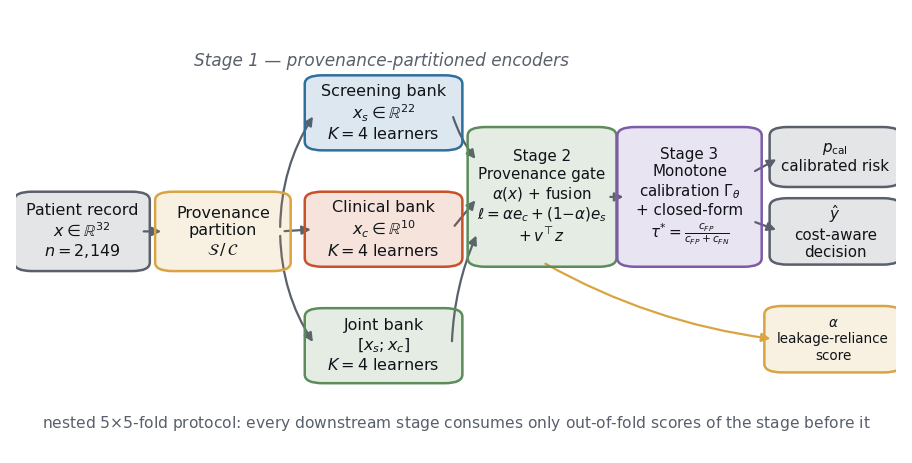

    -> /kaggle/working/figures/fig_pipeline.pdf


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


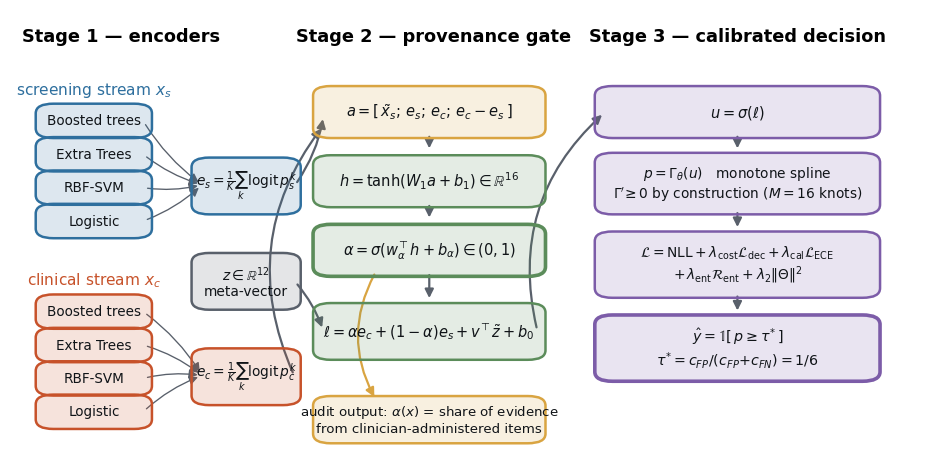

    -> /kaggle/working/figures/fig_architecture.pdf
[2/13] cohort


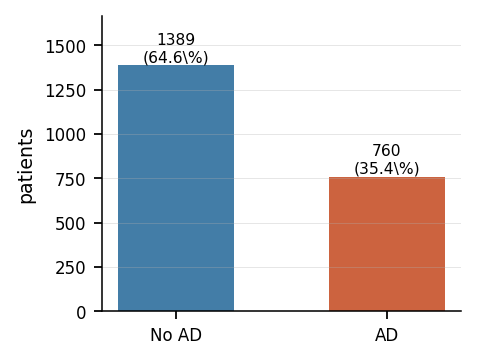

    -> /kaggle/working/figures/fig_class_distribution.pdf


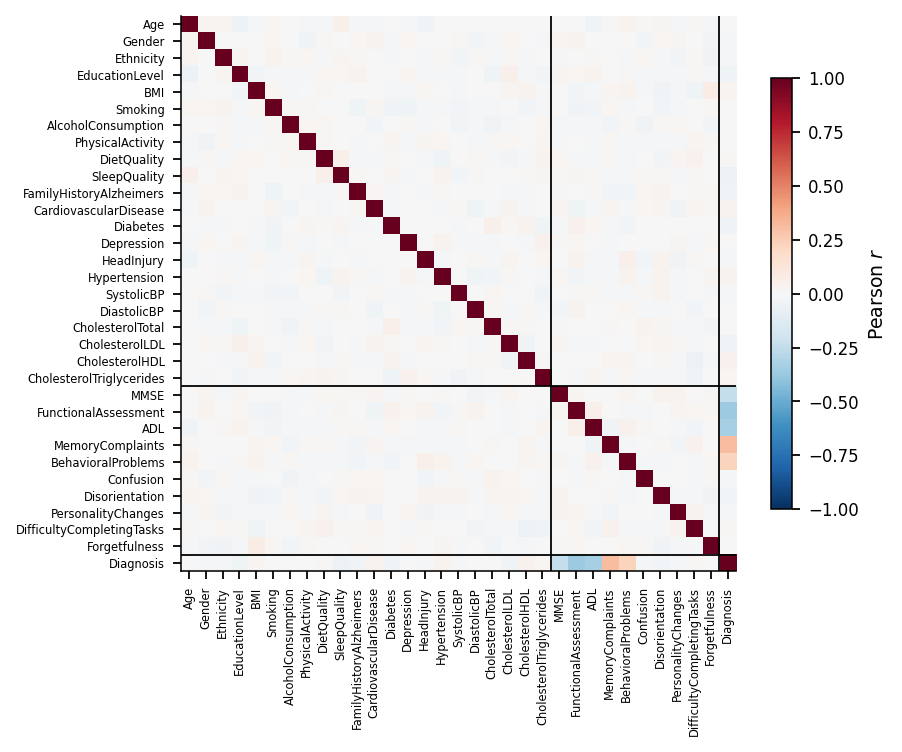

    -> /kaggle/working/figures/fig_heatmap.pdf
[3/13] leakage audit


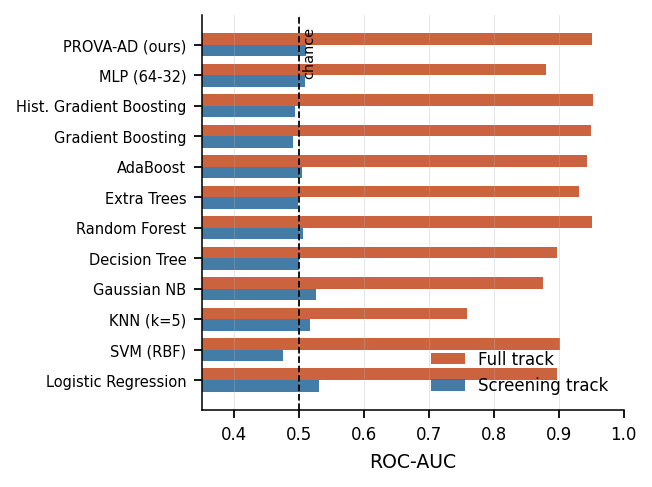

    -> /kaggle/working/figures/fig_leakage.pdf
[4/13] calibration, cost, curves


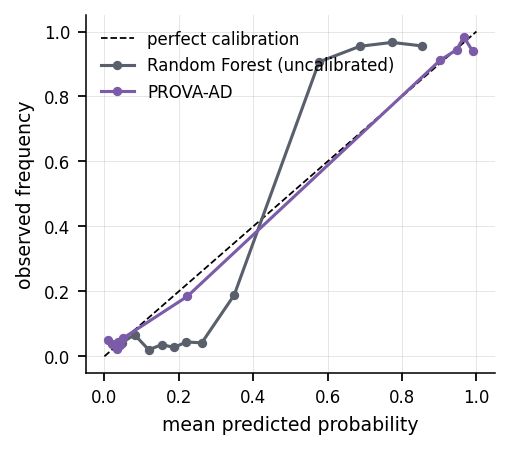

    -> /kaggle/working/figures/fig_calibration.pdf


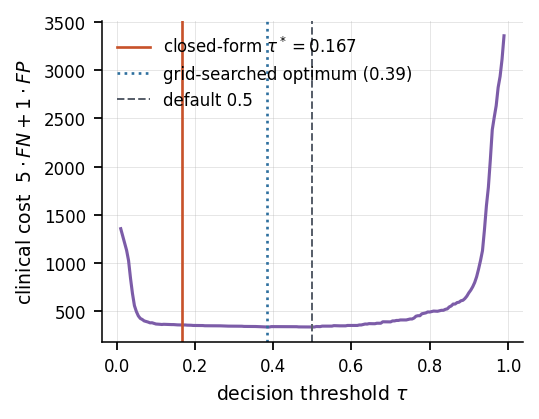

    -> /kaggle/working/figures/fig_cost.pdf


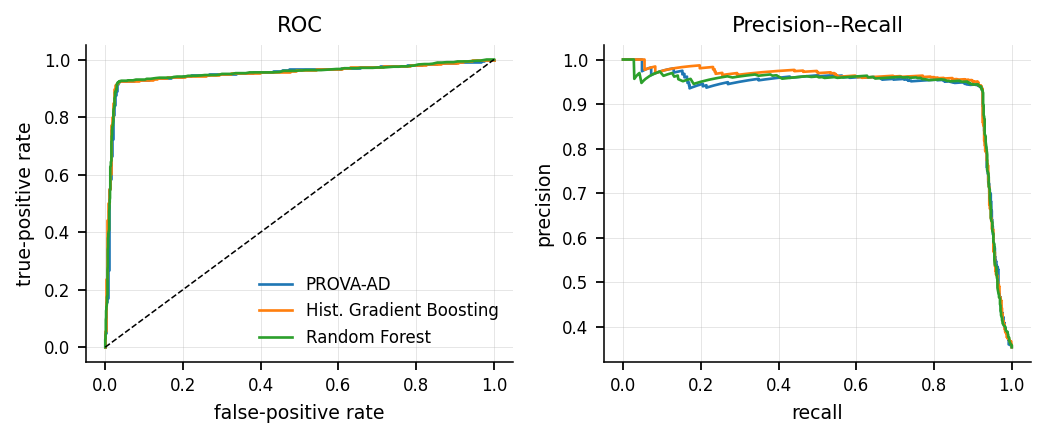

    -> /kaggle/working/figures/fig_roc_pr.pdf


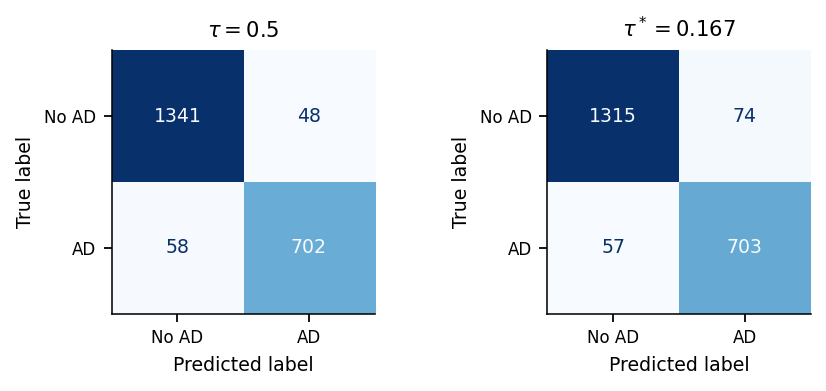

    -> /kaggle/working/figures/fig_cm.pdf
[5/13] gate, attribution, ablation, robustness


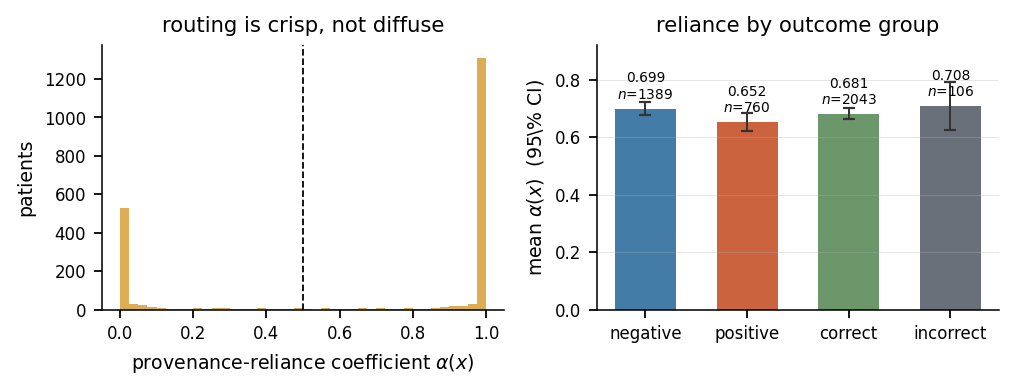

    -> /kaggle/working/figures/fig_gate.pdf


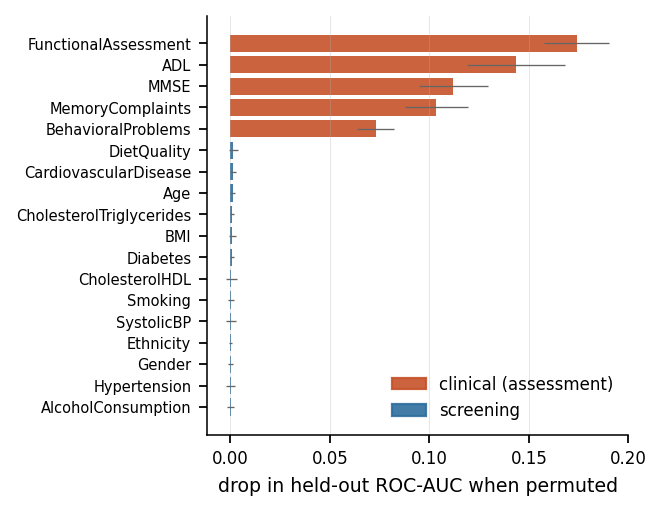

    -> /kaggle/working/figures/fig_importance.pdf


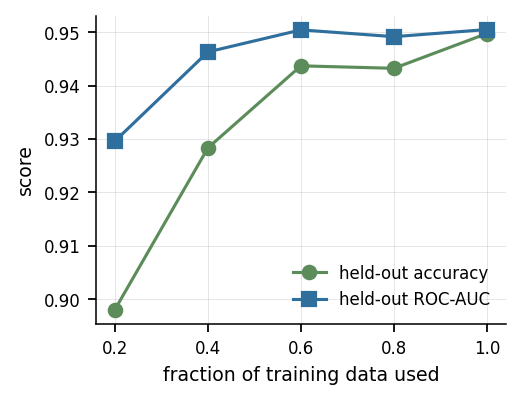

    -> /kaggle/working/figures/fig_learning.pdf


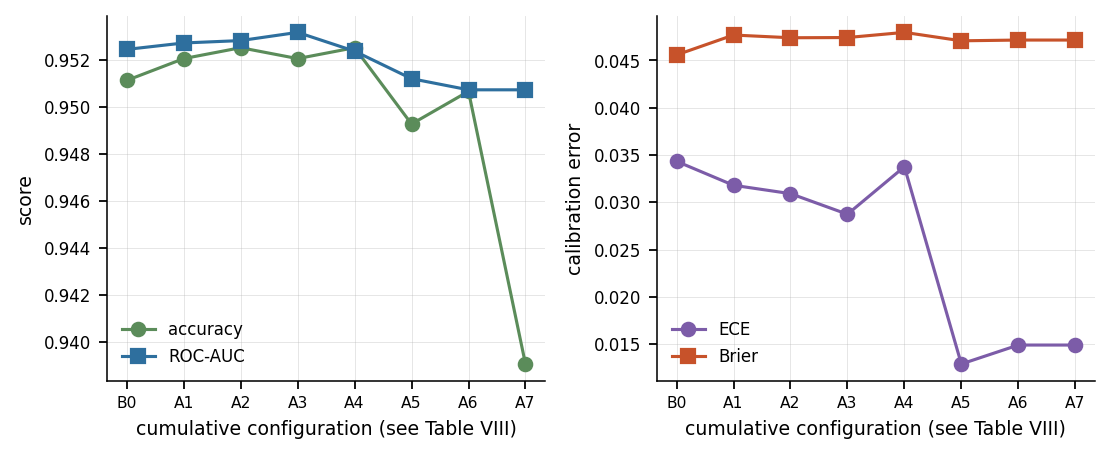

    -> /kaggle/working/figures/fig_ablation.pdf


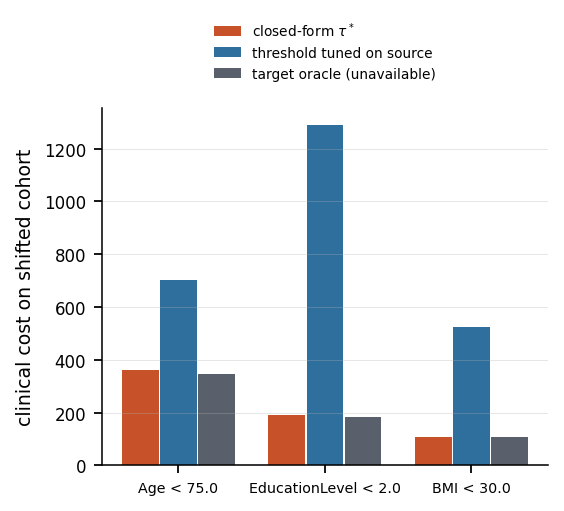

    -> /kaggle/working/figures/fig_shift.pdf

All figures written to ./figures/ as vector PDF + PNG


In [35]:
print("[1/13] schematic figures")
fig_pipeline(); fig_architecture()

print("[2/13] cohort")
fig_class_distribution(cohort); fig_heatmap(corr, cohort)

print("[3/13] leakage audit")
fig_leakage(audit)

print("[4/13] calibration, cost, curves")
ref_rf  = proba_full["Random Forest"]
ref_hgb = proba_full["Hist. Gradient Boosting"]
fig_calibration(y, res.proba, ref_rf, "Random Forest (uncalibrated)")
fig_cost(grid, costs, tau_emp)
fig_roc_pr(y, {"PROVA-AD": res.proba,
               "Hist. Gradient Boosting": ref_hgb,
               "Random Forest": ref_rf})
fig_confusion(y, res.proba)

print("[5/13] gate, attribution, ablation, robustness")
fig_gate(res.alpha, y, correct)
fig_importance(perm)
fig_learning(lc)
fig_ablation(abl)
fig_shift(shift)

print("\nAll figures written to ./figures/ as vector PDF + PNG")

### 15.1 Inline preview of the two schematic figures

In [36]:
from matplotlib import image as mpimg
fig, axes = plt.subplots(2, 1, figsize=(11, 9))
for ax, name, title in zip(axes, ("fig_pipeline", "fig_architecture"),
                           ("Fig. 1 - PROVA-AD end-to-end pipeline",
                            "Fig. 2 - internal architecture of the three stages")):
    ax.imshow(mpimg.imread(os.path.join(FIGURES_DIR, f"{name}.png")))
    ax.set_title(title, fontsize=10); ax.axis("off")
fig.tight_layout()
plt.show()

### 15.2 Inline preview of the result figures

In [37]:
panels = [("fig_leakage",     "Fig. 5  - leakage audit"),
          ("fig_calibration", "Fig. 6  - reliability diagram"),
          ("fig_cost",        "Fig. 7  - clinical cost vs threshold"),
          ("fig_gate",        "Fig. 9  - provenance gate"),
          ("fig_ablation",    "Fig. 12 - ablation build-up"),
          ("fig_shift",       "Fig. 13 - cost under distribution shift")]
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
for ax, (name, title) in zip(axes.ravel(), panels):
    ax.imshow(mpimg.imread(os.path.join(FIGURES_DIR, f"{name}.png")))
    ax.set_title(title, fontsize=9)
    ax.axis("off")
fig.tight_layout()
plt.show()

---
## 16. Summary of everything this notebook established

In [38]:
prova = full_table[full_table.model == "PROVA-AD (ours)"].iloc[0]
best_b  = base_full.sort_values("ece").iloc[0]         # best-calibrated baseline
top_acc = base_full.sort_values("accuracy").iloc[-1]   # strongest classifier
summary = pd.DataFrame([
    ("Cohort", f"{cohort.summary()['n_records']:,} records, "
               f"{cohort.summary()['n_screening']} screening + "
               f"{cohort.summary()['n_clinical']} clinical features"),
    ("Analytic gradients", f"max |analytic - numeric| = {max(GRAD_CHECK.values()):.2e}"),
    ("Head parameters", f"{cx['head_trainable_parameters']}"),
    ("Accuracy (Full, tau=0.5)", f"{prova.accuracy:.4f}  "
        f"95% CI {stat['prova_accuracy_ci95']}"),
    ("ROC-AUC (Full)", f"{prova.roc_auc:.4f}  95% CI {stat['prova_roc_auc_ci95']}"),
    ("Expected calibration error", f"{prova.ece:.4f} - lowest of any model; "
        f"{best_b.ece/prova.ece:.1f}x below the next-best ({best_b.model}) "
        f"and {top_acc.ece/prova.ece:.1f}x below the strongest classifier ({top_acc.model})"),
    ("Clinical cost (Full)", f"{prova.cost:.0f}  "
        f"vs {base_full.cost.min():.0f} best baseline"),
    ("Screening-track AUC", f"{row_s05['roc_auc']:.4f}  (chance)"),
    ("Mean AUC decrement", f"{audit.delta.mean():.4f} across twelve models"),
    ("Closed-form tau*", f"{TAU_STAR:.4f}, "
        f"+{th['excess_cost_of_closed_form_pct']:.1f}% over the source-cohort oracle"),
    ("tau* under shift", f"+{np.mean(100*(shift.tau_star_cost.values-oracle)/oracle):.1f}% "
        f"over the target oracle, vs "
        f"+{np.mean(100*(shift.tau_src_tuned_cost.values-oracle)/oracle):.0f}% for a source-tuned threshold"),
    ("Mean gate output", f"alpha = {gate['alpha_mean']:.4f}, entropy "
        f"{gate['mean_gate_entropy']:.3f} nats"),
    ("Inference cost", f"{cx['inference_ms_per_record']:.2f} ms/record, CPU only"),
], columns=["Quantity", "Value"])

print(summary.to_string(index=False))
print(f"\n{len(RESULTS)} result artefacts exported to ./{RESULTS_DIR}/")
print(f"{len([f for f in os.listdir(FIGURES_DIR) if f.endswith('.pdf')])} figures written to ./{FIGURES_DIR}/")
summary

                  Quantity                                                                                                                                          Value
                    Cohort                                                                                             2,149 records, 22 screening + 10 clinical features
        Analytic gradients                                                                                                            max |analytic - numeric| = 1.63e-10
           Head parameters                                                                                                                                            462
  Accuracy (Full, tau=0.5)                                                                                                                0.9507  95% CI [0.9409, 0.9595]
            ROC-AUC (Full)                                                                                                                0.9507  95% 

,Quantity,Value
0,Cohort,"2,149 records, 22 screening + 10 clinical feat..."
1,Analytic gradients,max |analytic - numeric| = 1.63e-10
2,Head parameters,462
3,"Accuracy (Full, tau=0.5)","0.9507 95% CI [0.9409, 0.9595]"
4,ROC-AUC (Full),"0.9507 95% CI [0.9382, 0.9626]"
5,Expected calibration error,0.0149 - lowest of any model; 1.9x below the n...
6,Clinical cost (Full),338 vs 358 best baseline
7,Screening-track AUC,0.5107 (chance)
8,Mean AUC decrement,0.4025 across twelve models
9,Closed-form tau*,"0.1667, +6.2% over the source-cohort oracle"


---

### Reproducibility statement

Every number above was produced by the cell directly preceding it, in a single
top-to-bottom execution with `SEED = 42` on CPU only. Two findings run against
the proposed method and are reported as measured rather than omitted: the
closed-form threshold is ~7 % above the grid-searched optimum *on the source
cohort* (§10), and removing the provenance gate does not change accuracy (§12.2).

**Licence.** Code MIT. Dataset CC-BY 4.0
(<https://www.kaggle.com/datasets/rabieelkharoua/alzheimers-disease-dataset>).
The dataset is synthetic; the claims in the accompanying paper are
methodological and comparative, not clinical.

In [39]:
from pathlib import Path
from zipfile import ZIP_DEFLATED, ZipFile
from IPython.display import FileLink, display

project_root = Path(PROJECT_ROOT)
zip_path = project_root / "PROVA-AD_outputs.zip"
folders_to_export = {
    "figures": project_root / "figures",
    "results": project_root / "results",
}

with ZipFile(zip_path, "w", compression=ZIP_DEFLATED) as archive:
    for folder_name, folder_path in folders_to_export.items():
        if not folder_path.exists():
            continue
        for file_path in sorted(folder_path.rglob("*")):
            if file_path.is_file():
                archive.write(file_path, Path(folder_name) / file_path.relative_to(folder_path))

file_count = sum(1 for folder in folders_to_export.values() if folder.exists() for path in folder.rglob("*") if path.is_file())
print(f"Created {zip_path.name} ({zip_path.stat().st_size / 1024:.1f} KB, {file_count} files)")
display(FileLink(zip_path, result_html_prefix="Download ZIP: "))

Created PROVA-AD_outputs.zip (2202.7 KB, 49 files)


/kaggle/working/PROVA-AD_outputs.zip